/tmp/ipykernel_845281/3164830208.py:135: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(samples))


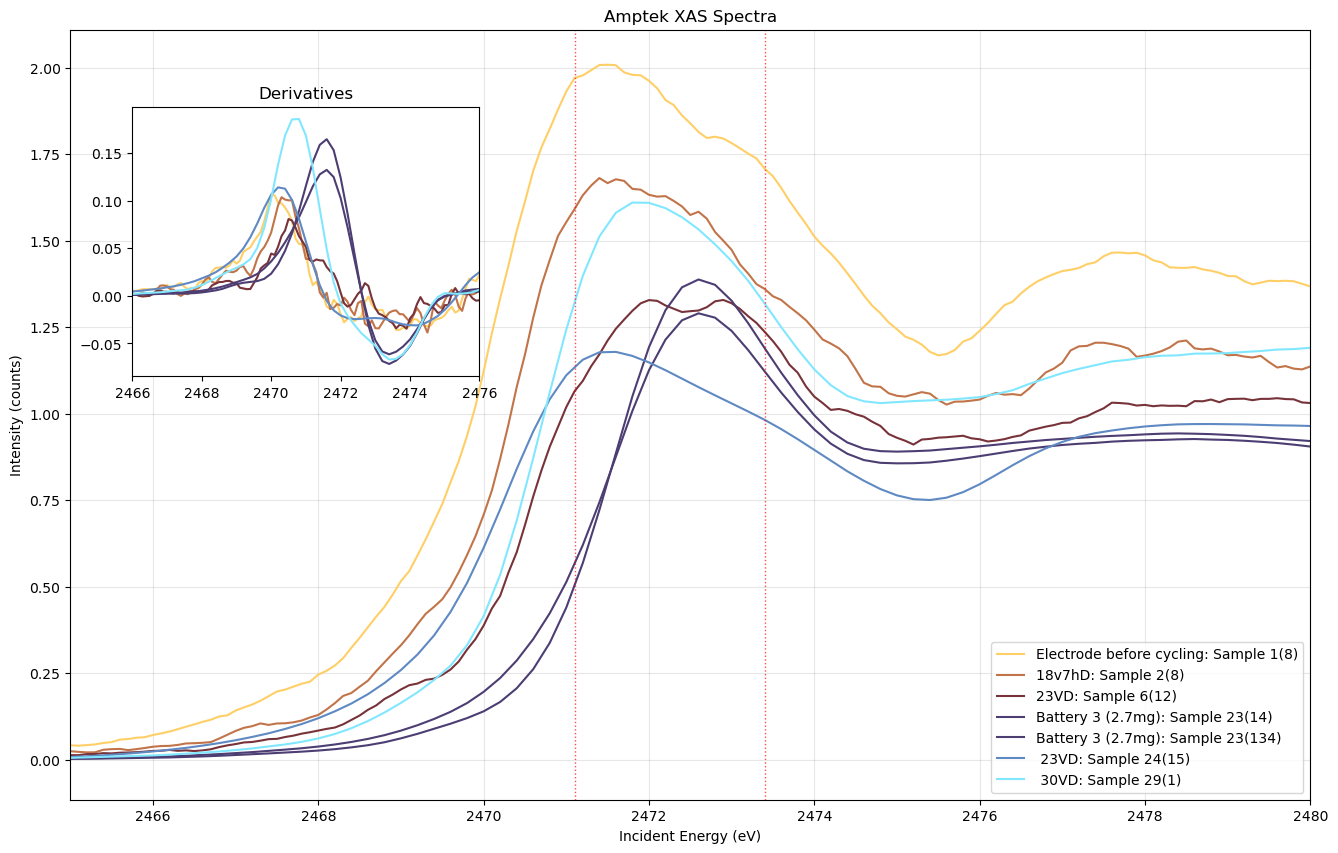

In [2]:
from dataclasses import dataclass, field
from enum import Enum, auto
from importlib.metadata import metadata
from pathlib import Path
from typing import List, Dict, Optional, Any

from scipy.signal import savgol_filter
import numpy as np
import os
import h5py
from dotenv import load_dotenv
import importlib
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec
from lmfit.models import PolynomialModel, GaussianModel, LinearModel, LorentzianModel, VoigtModel
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import logging
import warnings
__Analysis__ = "Analysis"

from Comparison_Pilatus import col_index

logging.basicConfig(level=logging.INFO, format='%(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__Analysis__)


def load_scans (sample_number: int,
                scans = dict['str', list],
                roi_id: Optional[int] = " ",
                kind: str = 'Amptek',
                smooth: Optional[int] = 1) -> Optional[pd.Series]:
    """ load specified scans from the h5 files that combine all scans of a sample. return df with all the data interpolated onto the same energy axis if needed"""

    path = f"Sample_{sample_number:04d}.h5"
    if not Path(path).exists():
        logger.error(f"Sample {sample_number:04d} does not exist")
        return None
    dfs = []
    with h5py.File(path, 'r') as f:
        sample_name = f["metadata"]["name"][()].decode("utf-8")

        for scan_number in scans[str(sample_number)]:
            scan_key = f"{scan_number:04d}"
            if scan_key not in f["scans"]:
                logger.error(f"Scan {scan_number:04d} does not exist in sample {sample_number:04d}")
                continue
            scan_grp = f["scans"][scan_key]


            if kind == 'Amptek':
                if "Amptek_XAS" not in scan_grp:
                    logger.error(f"Amptek_XAS not found in scan {scan_number:04d} of sample {sample_number:04d}")
                    continue
                data = scan_grp["Amptek_XAS"]["spectrum"][:]
                df = pd.DataFrame(data, columns=["incident_energy", "intensity","intensity_2", "I01", "I02"]),
                dfs.append(df)


    energy_ax = dfs[0][0]["incident_energy"]
    summed_intensity = np.zeros_like(energy_ax)

    for df in dfs:
        interpolated_intensity = np.interp(energy_ax, df[0]["incident_energy"], df[0]["intensity"])
        summed_intensity += interpolated_intensity


    if smooth and smooth > 1:
        smoothed = pd.Series(summed_intensity).rolling(window=smooth, center=True).mean().to_numpy()
        if smooth % 2 == 0:
            smooth += 1
        order = min (3, smooth - 1)  # Ensure polyorder is less than window_length
        smoothed = savgol_filter(summed_intensity, window_length=smooth, polyorder=order)#rolling mean for smoothing
    else:
        smoothed = summed_intensity

    df = pd.Series(data=smoothed, index=pd.Series(energy_ax, name="energy [eV]"), name=sample_name + ": Sample " + str(sample_number) + f"({scan_number})")
    return df


def nomalize_xas(df: pd.Series, flat = False, plot = False) -> pd.Series:
    #first find pre-edge line and subtract from entire spectrum
    if plot:
        fig,ax = plt.subplots(1, 1, figsize=(16, 10))
        ax.plot(df.index,df.values, color = 'black', label = "data")


    pre_edge = df[df.index < 2465]
    pre_line = np.polyfit(pre_edge.index, pre_edge.values, 1)
    pre_baseline = np.polyval(pre_line, df.index)
    pre_edge_normalized = df - pre_baseline
    if plot:
        ax.plot(df.index,pre_baseline, color = 'red', ls = '--', label = "pre-edge")

    #then fit a function to last part of spectra, evaluate it at e0 (max derivative) and normalize wit that

    post_edge = df[df.index > 2485]
    post_line = np.polyfit(post_edge.index, post_edge.values, 1)
    post_baseline = np.polyval(post_line, df.index)
    max_der= np.argmax(np.gradient(pre_edge_normalized))
    e0 = df.index[max_der]
    edge_step = np.polyval(post_line, e0) - np.polyval(pre_line, e0)
    normalized = pre_edge_normalized/edge_step

    norm_df = pd.Series(data=normalized, index=pd.Series(df.index, name="energy [eV]"), name=df.name)
    if plot:
        ax.plot(df.index,post_baseline, color = 'red', ls = '--', label = "post-edge")
        ax.axvline(e0, color='green', ls=':', label='E0')

    #flatten by fitting a quadratic function to the end and subtract that from the espectrum above e0

    if flat:
        post_edge = norm_df[norm_df.index > 2480] #maybe set both limits, idk why it doesn't normalize properly
        quadratic = np.polyfit(post_edge.index, post_edge.values, 1)
        baseline = np.polyval(quadratic, norm_df.index)


        flat = (norm_df - baseline) + baseline[max_der]
        flat.iloc[:max_der] = normalized.iloc[:max_der]


        if plot:
            ax.plot(df.index, (baseline*edge_step) , color='blue', ls='--', label="quad")
            ax.plot(post_edge.index,post_edge.values, linewidth = 10, alpha = 0.3)
        return  flat

    else:
        return norm_df


def plot_xas(samples: List[int], scans: Dict[str, List[int]], kind: str = 'Amptek', cmap_name='viridis'):
    cmap_name = 'managua'
    fig, ax = plt.subplots(1, 1, figsize=(16, 10))
    axin1 = ax.inset_axes([0.05, 0.55, 0.28, 0.35])

    cmap = cm.get_cmap(cmap_name, len(samples))
    norm = mcolors.Normalize(vmin=0, vmax=len(samples) - 1)
    for i, sample in enumerate(samples):
        temp_dict = {}
        #cmap = cm.get_cmap(cmap_name, len(scans[str(sample)]))
        #norm = mcolors.Normalize(vmin=0, vmax=len(scans[str(sample)]) - 1)

        for j, scan in enumerate(scans[str(sample)]):
            temp_dict[str(sample)] = [scan]
            df = load_scans(sample, temp_dict, kind=kind, smooth=10)
            df = nomalize_xas(df, plot=False, flat = True)
            data = df.to_numpy()
            if df is None:
                continue

            color = cmap(norm(i))


            ax.plot(df.index, data, label=df.name, color=color)
            axin1.plot(df.index, np.gradient(data), color=color)

    ax.set_xlabel("Incident Energy (eV)")
    ax.set_ylabel("Intensity (counts)")
    ax.set_title("Amptek XAS Spectra")
    ax.legend(loc = 'lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(2465,2480)

    battery_lines = [2471.1, 2473.4,2482.5]
    for line in battery_lines:
        ax.axvline(line, color='red', ls=':', alpha = 0.7, linewidth = 1)

    axin1.set_xlim(2466, 2476)
    axin1.set_title("Derivatives")








samples = [1,2,6,23,24,29]
scans = {'1':[8],
    '2':[8],
         '6': [12],
         '23':  [14,134],
         '24': [15],
         '29': [1]}
plot_xas(samples, scans)

In [3]:
import numpy as np
import matplotlib.pyplot as plt

rows = []
with open('/home/ava/Documents/2025/GALAXIES25/in-operando-EC.txt') as f:
    for i,line in enumerate(f):
        if i < 4:   continue
        # split on whitespace, convert to float (or int)
        row = line.strip().split()
        row = [float(x) for x in row]  # or int(x)
        rows.append(row)

print(rows)

[[1.20704e-05, 2.92457, 20.16667, 2.75819, 0.0, 2.83558, 20.0, 2.83779], [0.31018, 2.75819, 20.33334, 2.71528, 0.0, 2.8357, 20.00001, 2.69987], [0.62033, 2.71528, 20.50001, 2.67739, 0.0, 2.83566, 20.16667, 2.47522], [0.93046, 2.67739, 20.66667, 2.64382, 0.0, 2.83572, 20.33334, 2.4362], [1.2406, 2.64382, 20.83334, 2.61324, 0.0, 2.83571, 20.50001, 2.40833], [1.55073, 2.61324, 21.00001, 2.58514, 0.0, 2.83574, 20.66667, 2.38643], [1.86086, 2.58514, 21.16667, 2.55947, 0.0, 2.83569, 20.83334, 2.36853], [2.17099, 2.55947, 21.33334, 2.53604, 0.0, 2.83575, 21.00001, 2.35334], [2.48113, 2.53604, 21.50001, 2.51416, 0.0, 2.83563, 21.16667, 2.33994], [2.79126, 2.51416, 21.66667, 2.49388, 0.0, 2.8358, 21.33334, 2.32798], [3.1014, 2.49388, 21.83334, 2.47491, 0.0, 2.83591, 21.50001, 2.31762], [3.41154, 2.47491, 22.00001, 2.45762, 0.0, 2.8359, 21.66667, 2.30796], [3.7217, 2.45762, 22.16667, 2.44113, 0.0, 2.83598, 21.83334, 2.29897], [4.03186, 2.44113, 22.33334, 2.42638, 0.0, 2.83592, 22.00001, 2.29101]

In [4]:
capacity_3 = [r[0] for r in rows if r]
voltage_3 = [r[1] for r in rows if r]
time_3 = [r[2] for r in rows if len(r) > 2]
voltage2_3 = [r[3] for r in rows if len(r) > 3]

capacity_2 = [r[4] for r in rows if len(r) > 4]
voltage_2 = [r[5] for r in rows if len(r) > 5]
time_2 = [r[6] for r in rows if len(r) > 6]
voltage2_2 = [r[7] for r in rows if len(r) > 7]

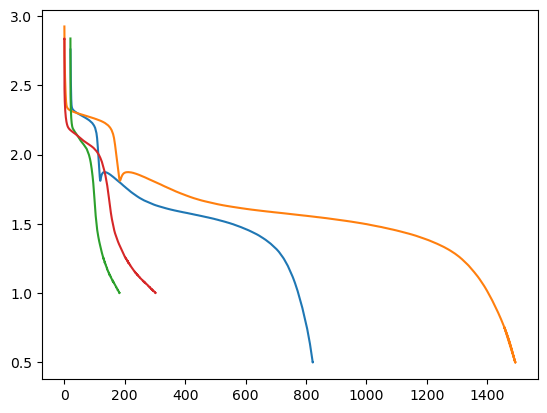

In [5]:
plt.plot(time_3, voltage2_3)
plt.plot(capacity_3, voltage_3)
plt.plot(time_2, voltage2_2)
plt.plot(capacity_2, voltage_2)

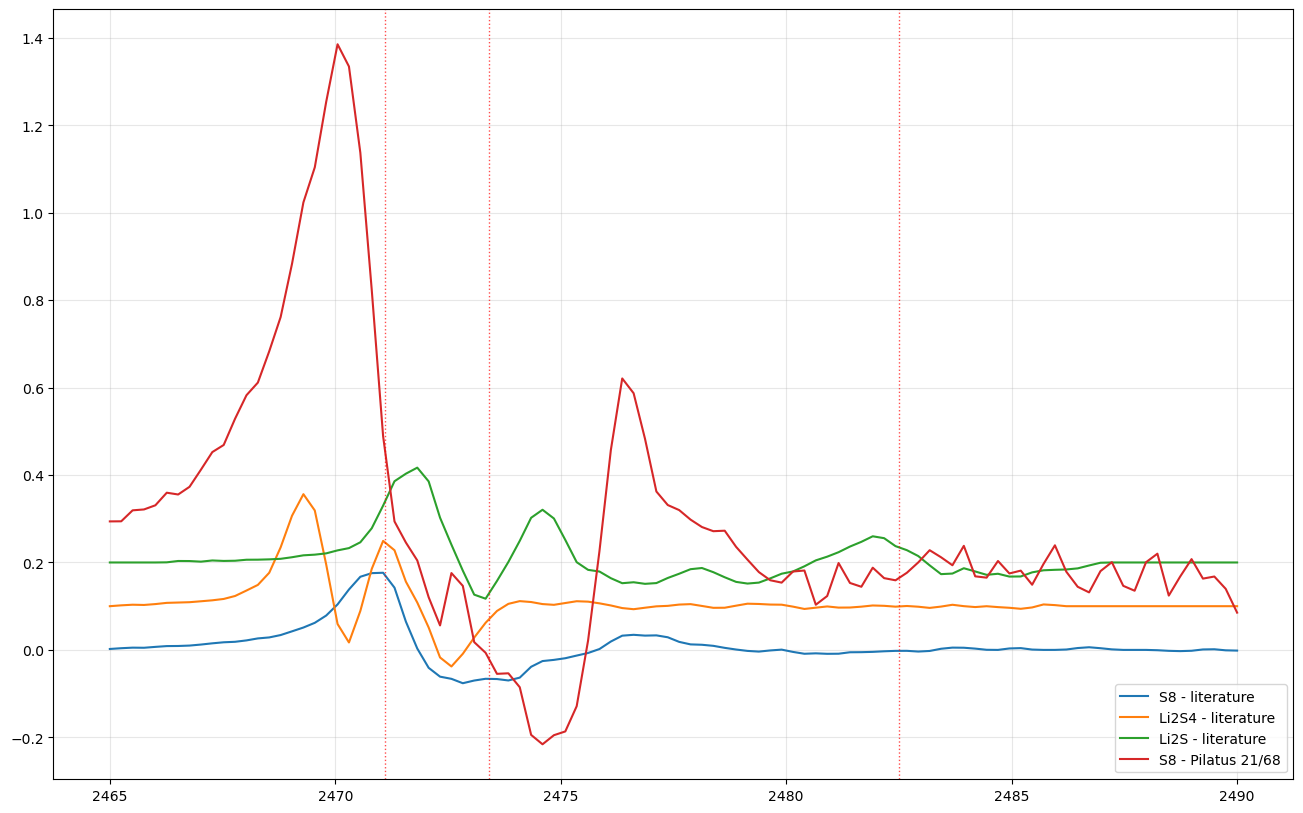

In [174]:
def fit_N_gaus(N, x, y, el_energy, plot = True):
    "fit N gaussian fuction to the derivative of data"
    models = []
    for i in range(N+1):
        g = GaussianModel(prefix=f'g{i}_')
        models.append(g)
    model = models[0]
    for m in models[1:]:
        model += m
    params = model.make_params()
    gauss_start_values = [2460.0, 2465,2455]




    for i in range(N+1):
        if i==0:
            params[f'g{0}_center'].set(value=el_energy)
            params[f'g{0}_sigma'].set(value=0.1, min=0.0001)
            params[f'g{0}_amplitude'].set(value=1, min=0)
        else:
            params[f'g{i}_center'].set(value=gauss_start_values[i-1] + (i-1)*0.15, min=gauss_start_values[i-1]-4.5, max=gauss_start_values[i-1]+4.5)
            params[f'g{i}_sigma'].set(value=0.1, min=0.0001)
            params[f'g{i}_amplitude'].set(value=1, min=0)
    result = model.fit(y, params, x=x)
    if plot:
        fig, ax = plt.subplots(1, 1, figsize=(16, 10))
        ax.plot(x, y, label='Data', color='black')
        ax.plot(x, result.best_fit, label='Fit', color='red')
        for i in range(N+1):
            if i==0:
                ax.plot(x, result.eval_components(x=x)[f'g{i}_'], label=f'Elastic Gaussian')
            else:
                ax.plot(x, result.eval_components(x=x)[f'g{i}_'], label=f'Gaussian {i+1}')
        ax.legend()
        ax.set_xlabel("Energy [eV]")
        ax.set_ylabel("Intensity")
        ax.grid(True, alpha=0.3)

    #return only position and amplitudes of peaks
    return {f'g{i}_center': result.params[f'g{i}_center'].value for i in range(N+1)}, {f'g{i}_amplitude': result.params[f'g{i}_amplitude'].value for i in range(N+1)}


def remove_background(x,y,energy=None, plot = False):
    "fit a combination of linear background and a gaussian to the data and subtract the linear function from the data"
    mask = ((x > 2445) & (x < 2450)) | ((x > 2470) & (x < 2480)) #roi2
    #mask = ((x > 2435) & (x < 2450)) | ((x > 2470) & (x < 2480)) #roi1

    x_fit = x[mask]
    y_fit = y[mask]
    gaussian_model = GaussianModel(prefix='g_')
    linear_model = LinearModel(prefix='l_')
    model = gaussian_model + linear_model
    params = model.make_params()

    params['g_amplitude'].set(value=np.max(y), min=0)
    params['g_center'].set(value=energy)
    params['g_sigma'].set(value=0.5)
    result = model.fit(y_fit, params, x=x_fit)


    elastic_mask = (x > energy - 2) & (x < energy + 2)

    line = result.eval_components(x=x)['l_']
    gauss = result.eval_components(x=x)['g_']

    y_corrected = y - line
    #y_masked = y_corrected.copy()
    #y_masked[elastic_mask] = gauss[elastic_mask]

    if plot:
        fig, ax = plt.subplots(1, 1, figsize=(16, 10))
        ax.plot(x,y, color = 'black', label='Original Data')
        ax.plot(x, line, color='red', label='Linear Background')
        ax.plot(x, gauss, color='blue', label='Gaussian Fit')
        ax.legend()
        ax.grid(True, alpha=0.3)

    return x, y_corrected



def normalize_intensity(x,y,limits=(2455, 2468)):
    low_limit = limits[0]
    upper_limit = limits[1]
    mask = (x > low_limit) & (x < upper_limit)
    x_fit = x[mask]
    y_fit = y[mask]
    area = np.trapezoid(y_fit, x=x_fit)
    max_height = np.max(y_fit)
    return x,y/area


def scale_to_elastic(x, y, energy):
    if energy < max(x):
        mask = (x> energy - 2) & (x < energy + 2)
        x_mask = x[mask]
        y_mask = y[mask]
        area = np.trapezoid(y_mask, x=x_mask)
        return x, y/area

    else:
        return x,y

def smooth_data(x, y, window_length=5, polyorder=2):
    """Smooth the data using a Savitzky-Golay filter."""
    if len(y) < window_length:
        logger.warning("Data length is shorter than window length. Skipping smoothing.")
        return x, y
    y_smooth = savgol_filter(y, window_length=window_length, polyorder=polyorder)
    return x, y_smooth



def nomalize_xas(df: pd.Series, flat = False, plot = False) -> pd.Series:
    #first find pre-edge line and subtract from entire spectrum
    if plot:
        fig,ax = plt.subplots(1, 1, figsize=(16, 10))
        ax.plot(df.index,df.values, color = 'black', label = "data")


    pre_edge = df[df.index < 2465]
    pre_line = np.polyfit(pre_edge.index, pre_edge.values, 1)
    pre_baseline = np.polyval(pre_line, df.index)
    pre_edge_normalized = df - pre_baseline
    if plot:
        ax.plot(df.index,pre_baseline, color = 'red', ls = '--', label = "pre-edge")

    #then fit a function to last part of spectra, evaluate it at e0 (max derivative) and normalize wit that

    post_edge = df[df.index > 2485]
    post_line = np.polyfit(post_edge.index, post_edge.values, 1)
    post_baseline = np.polyval(post_line, df.index)
    max_der= np.argmax(np.gradient(pre_edge_normalized))
    e0 = df.index[max_der]
    edge_step = np.polyval(post_line, e0) - np.polyval(pre_line, e0)
    normalized = pre_edge_normalized/edge_step

    norm_df = pd.Series(data=normalized, index=pd.Series(df.index, name="energy [eV]"), name=df.name)
    if plot:
        ax.plot(df.index,post_baseline, color = 'red', ls = '--', label = "post-edge")
        ax.axvline(e0, color='green', ls=':', label='E0')

    #flatten by fitting a quadratic function to the end and subtract that from the espectrum above e0

    if flat:
        post_edge = norm_df[norm_df.index > 2480] #maybe set both limits, idk why it doesn't normalize properly
        quadratic = np.polyfit(post_edge.index, post_edge.values, 1)
        baseline = np.polyval(quadratic, norm_df.index)


        flat = (norm_df - baseline) + baseline[max_der]
        flat.iloc[:max_der] = normalized.iloc[:max_der]


        if plot:
            ax.plot(df.index, (baseline*edge_step) , color='blue', ls='--', label="quad")
            ax.plot(post_edge.index,post_edge.values, linewidth = 10, alpha = 0.3)
        return  flat

    else:
        return norm_df

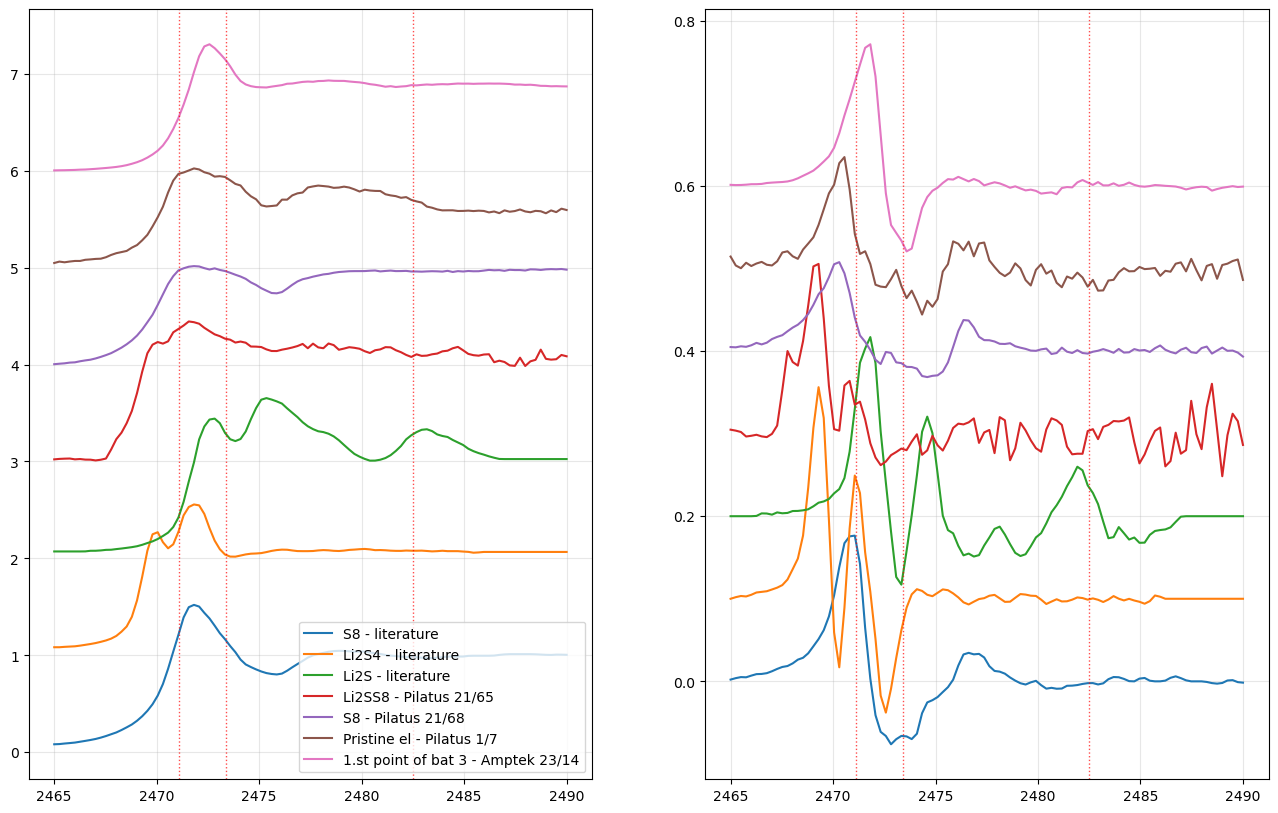

In [212]:
#S8 from tablet RIXS (pilatus)
S8 = np.loadtxt('/home/ava/Documents/2025/GALAXIES25/Analysis/Soleil25_Ava/cache/Electrode_021/scan_0068/spectrum_ROI2_pilatus_xas.csv', skiprows = 1, delimiter = ',')
x = S8[:,0]
y = S8[:,1]
df = pd.DataFrame({'value': y}, index=x)
dfn = nomalize_xas(df['value'] , flat = True, plot = False)
S8x = dfn.index
S8y = dfn.values

#S8 original from pristine electrode from RIXS (pilatus)
S8_o = np.loadtxt('/home/ava/Documents/2025/GALAXIES25/Analysis/Soleil25_Ava/cache/Electrode_001/scan_0007/spectrum_ROI2_pilatus_xas.csv', skiprows = 1, delimiter = ',')
x = S8_o[:,0]
y = S8_o[:,1]
df = pd.DataFrame({'value': y}, index=x)
dfn = nomalize_xas(df['value'] , flat = True, plot = False)
S8_ox = dfn.index
S8_oy = dfn.values

#presumed Li2S8 original from RIXS (pilatus)
Li2S8 = np.loadtxt('/home/ava/Documents/2025/GALAXIES25/Analysis/Soleil25_Ava/cache/Electrode_021/scan_0065/spectrum_ROI2_pilatus_xas.csv', skiprows = 1, delimiter = ',')

x = Li2S8[:,0]
y = Li2S8[:,1]
df = pd.DataFrame({'value': y}, index=x)
dfn = nomalize_xas(df['value'] , flat = True, plot = False)
Li2S8x = dfn.index
Li2S8y = dfn.values

standards = np.loadtxt('/home/ava/Documents/2025/GALAXIES25/wpd_datasets (1).csv', skiprows = 2, delimiter = ',')

#first point of battery
bat1 = np.loadtxt('/home/ava/Documents/2025/GALAXIES25/Analysis/Soleil25_Ava/cache/Electrode_023/scan_0014/spectrum_[220, 240]_amptek_xas.csv', skiprows = 1, delimiter = ',')

x = bat1[:,0]
y = bat1[:,1]
df = pd.DataFrame({'value': y}, index=x)
dfn = nomalize_xas(df['value'] , flat = True, plot = False)
bat1x = dfn.index
bat1y = dfn.values

fig,axs = plt.subplots(1, 2, figsize=(16, 10))

energy_ax = np.linspace(2465,2490,100)

ax = axs[1]
ax.plot(energy_ax, np.gradient(np.interp(energy_ax,standards[:,0], standards[:,1])), label = 'S8 - literature')
ax.plot(energy_ax, np.gradient(np.interp(energy_ax,standards[:,2] , standards[:,3]))+0.1,label = 'Li2S4 - literature')
ax.plot(energy_ax, np.gradient(np.interp(energy_ax,standards[:,4] , standards[:,5]))+0.2,label = 'Li2S - literature')

ax.plot(energy_ax, np.gradient(np.interp(energy_ax,Li2S8x , Li2S8y))+0.3,label = 'Li2SS8 - Pilatus 21/65')
ax.plot(energy_ax, np.gradient(np.interp(energy_ax,S8x , S8y))+0.4,label = 'S8 - Pilatus 21/68')
ax.plot(energy_ax, np.gradient(np.interp(energy_ax,S8_ox , S8_oy))*0.4+0.5,label = 'Pristine el - Pilatus 1/7')
ax.plot(energy_ax, np.gradient(np.interp(energy_ax,bat1x , bat1y))+0.6,label = '1.st point of bat 3 - Amptek 23/14')
ax.grid(True, alpha=0.3)
battery_lines = [2471.1, 2473.4,2482.5]
for line in battery_lines:
    ax.axvline(line, color='red', ls=':', alpha = 0.7, linewidth = 1)

ax = axs[0]
ax.plot(energy_ax, (np.interp(energy_ax,standards[:,0], standards[:,1])), label = 'S8 - literature')
ax.plot(energy_ax, (np.interp(energy_ax,standards[:,2] , standards[:,3])-0.65 + 1),label = 'Li2S4 - literature')
ax.plot(energy_ax, (np.interp(energy_ax,standards[:,4] , standards[:,5])-1.35 + 2),label = 'Li2S - literature')

ax.plot(energy_ax, (np.interp(energy_ax,Li2S8x , Li2S8y))+3,label = 'Li2SS8 - Pilatus 21/65')
ax.plot(energy_ax, (np.interp(energy_ax,S8x , S8y))+4,label = 'S8 - Pilatus 21/68')
ax.plot(energy_ax,(np.interp(energy_ax,S8_ox , S8_oy))*0.4+5,label = 'Pristine el - Pilatus 1/7')
ax.plot(energy_ax, (np.interp(energy_ax,bat1x , bat1y))+6,label = '1.st point of bat 3 - Amptek 23/14')

ax.legend(loc = 'lower right')
ax.grid(True, alpha=0.3)
battery_lines = [2471.1, 2473.4,2482.5]
for line in battery_lines:
    ax.axvline(line, color='red', ls=':', alpha = 0.7, linewidth = 1)

/tmp/ipykernel_845281/2867906003.py:27: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 1, figsize=(16, 10))


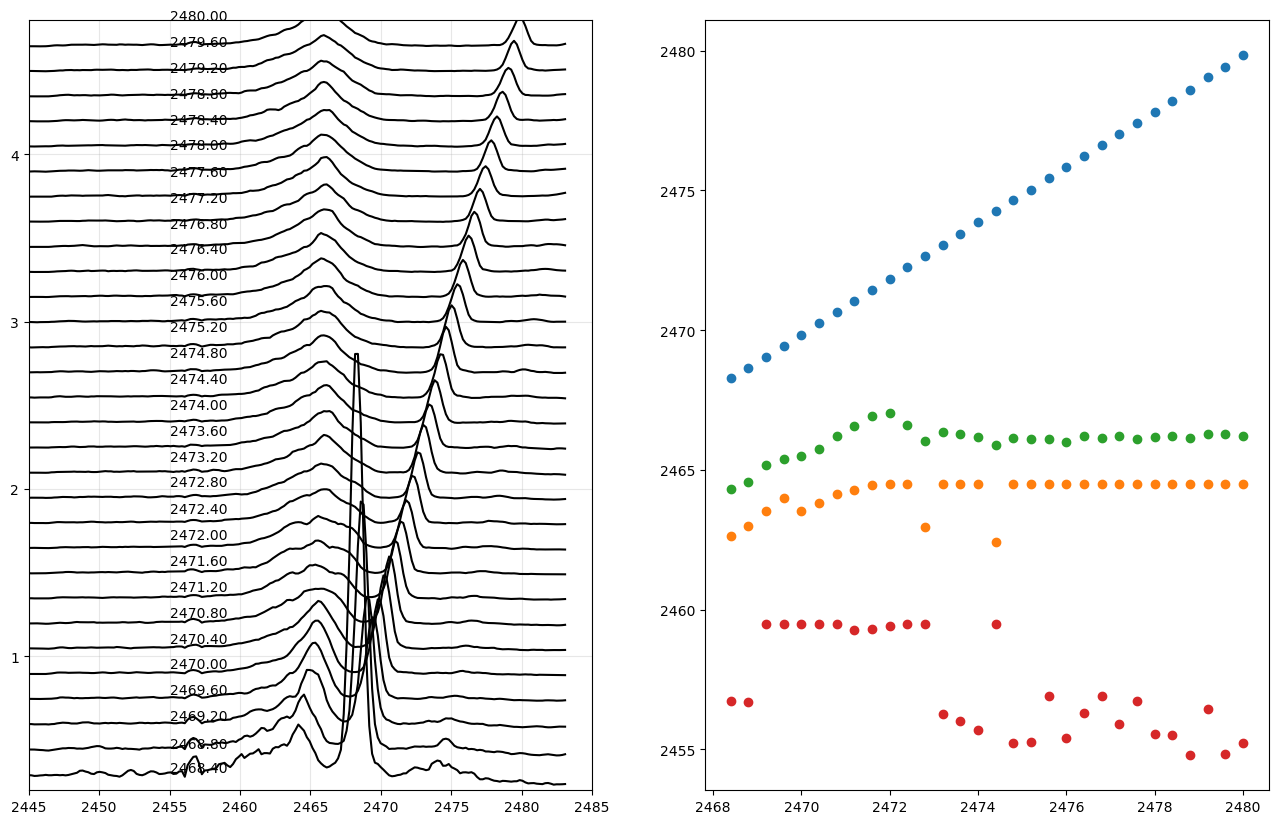

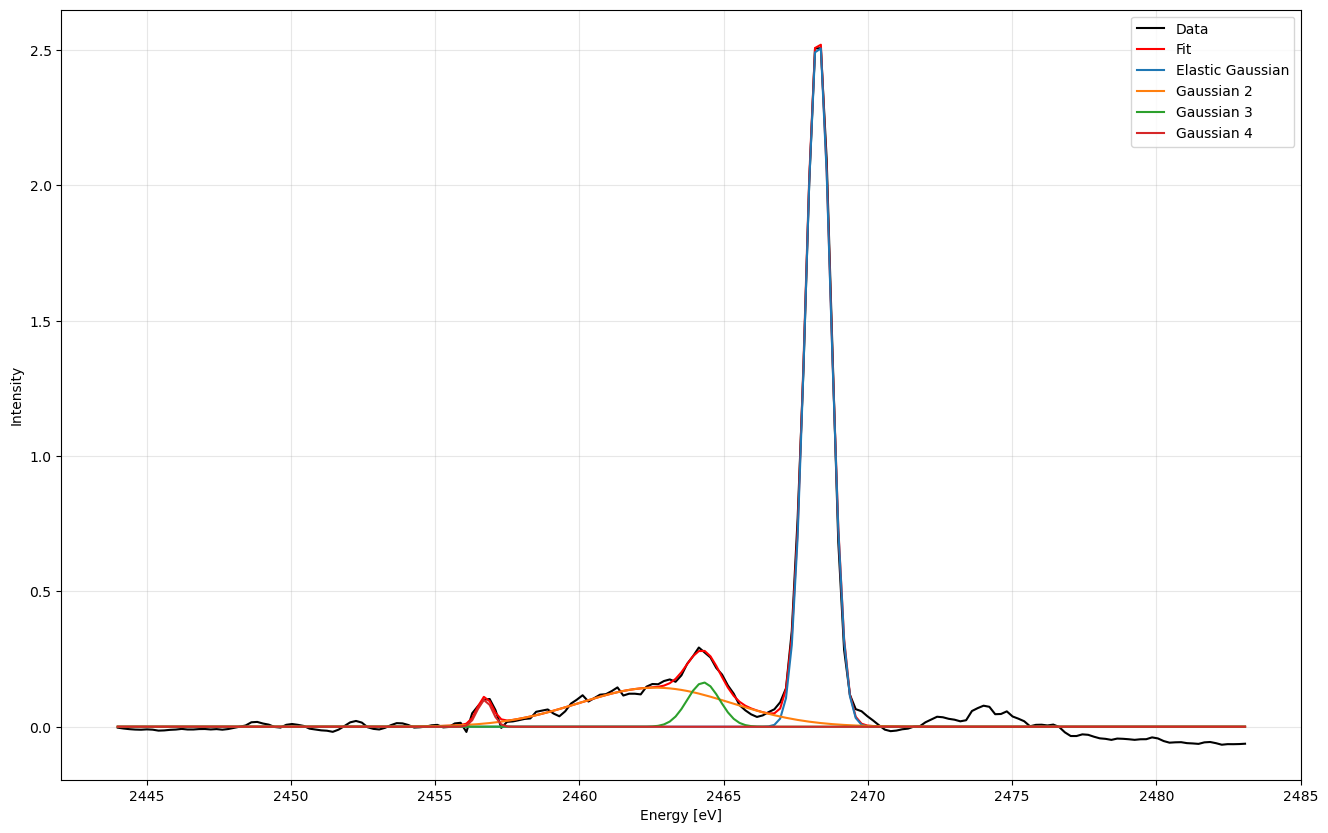

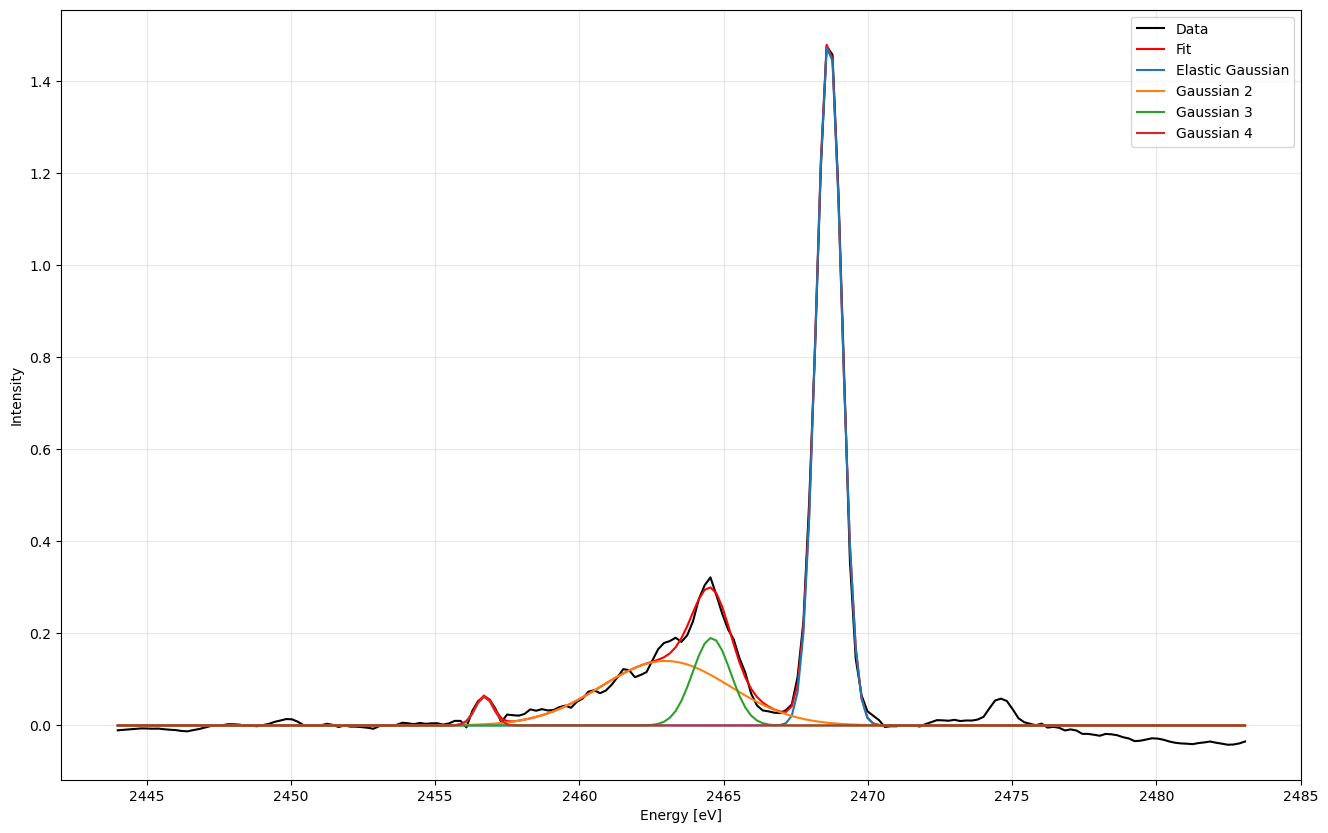

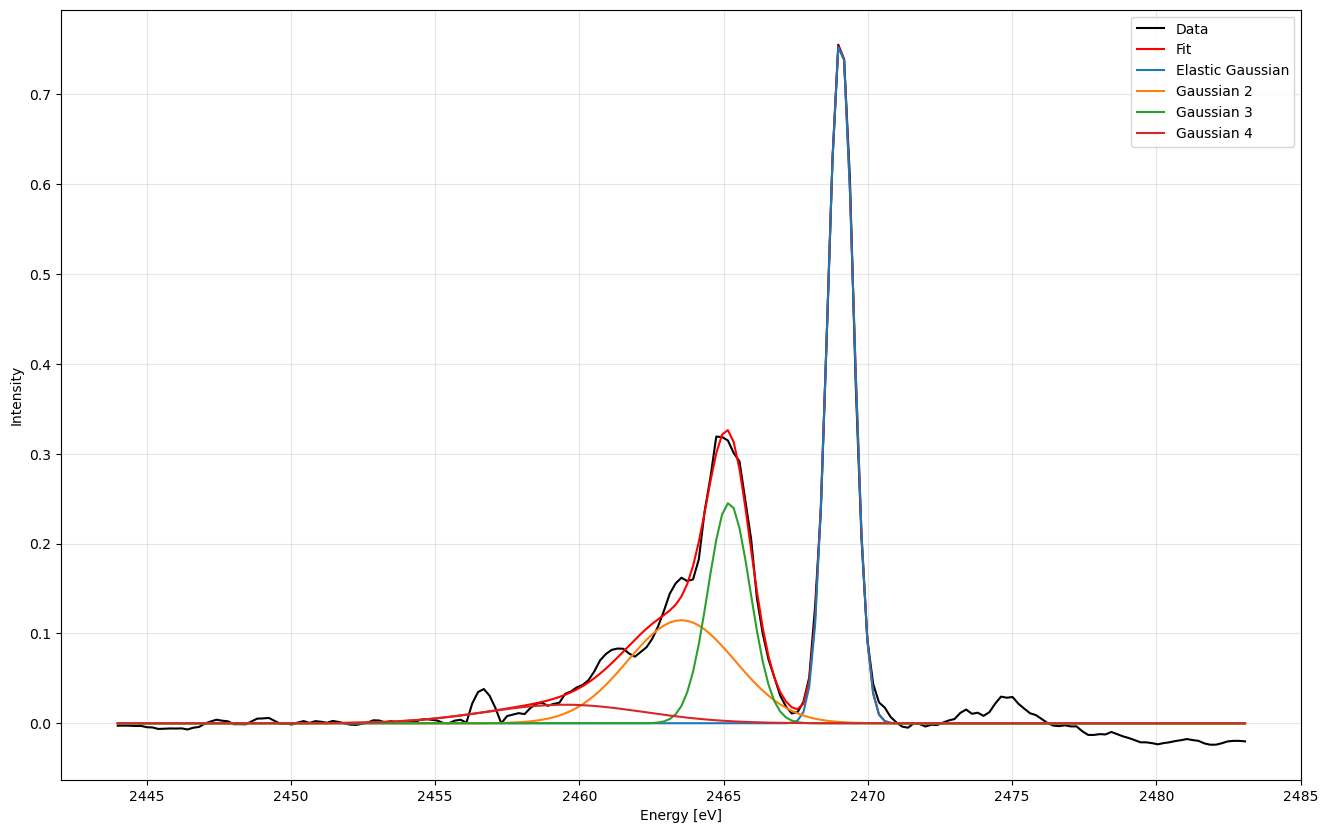

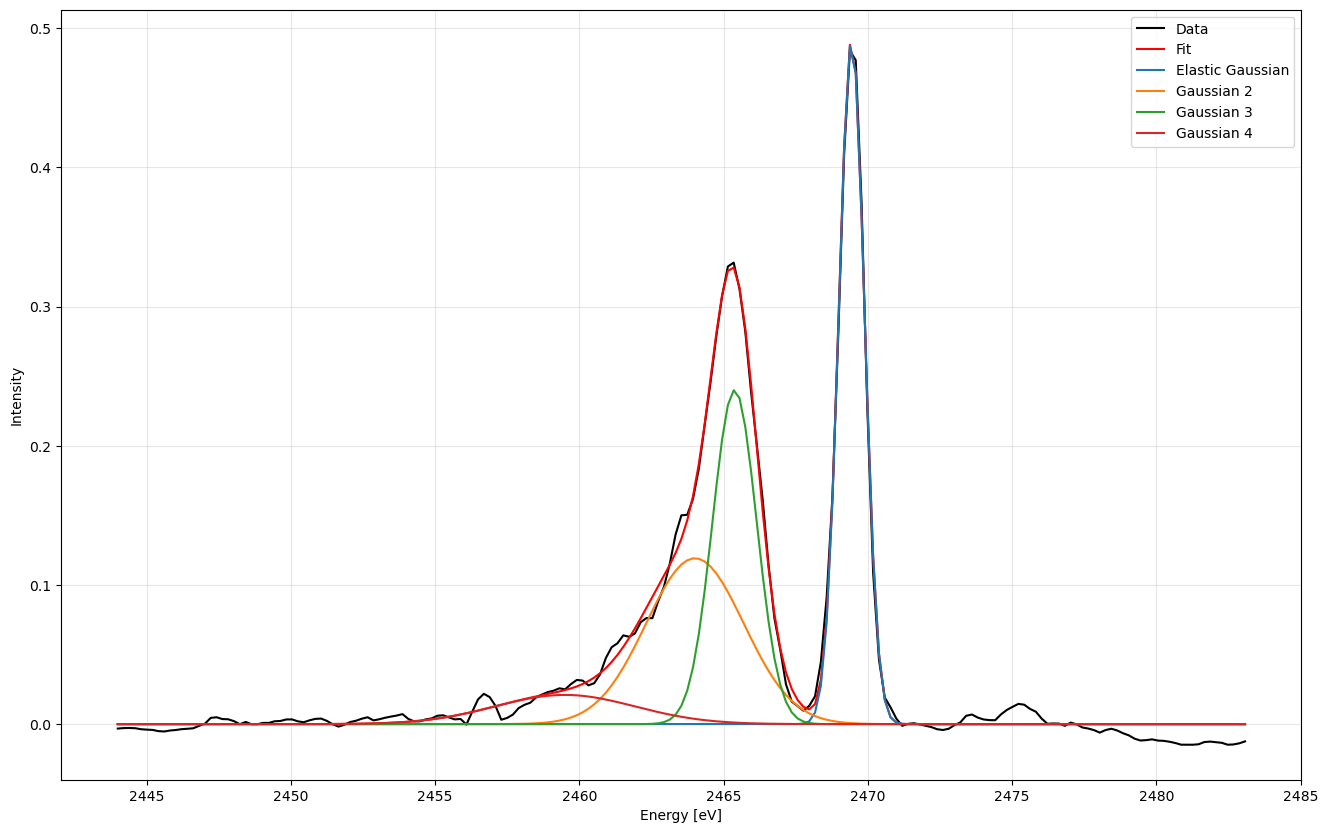

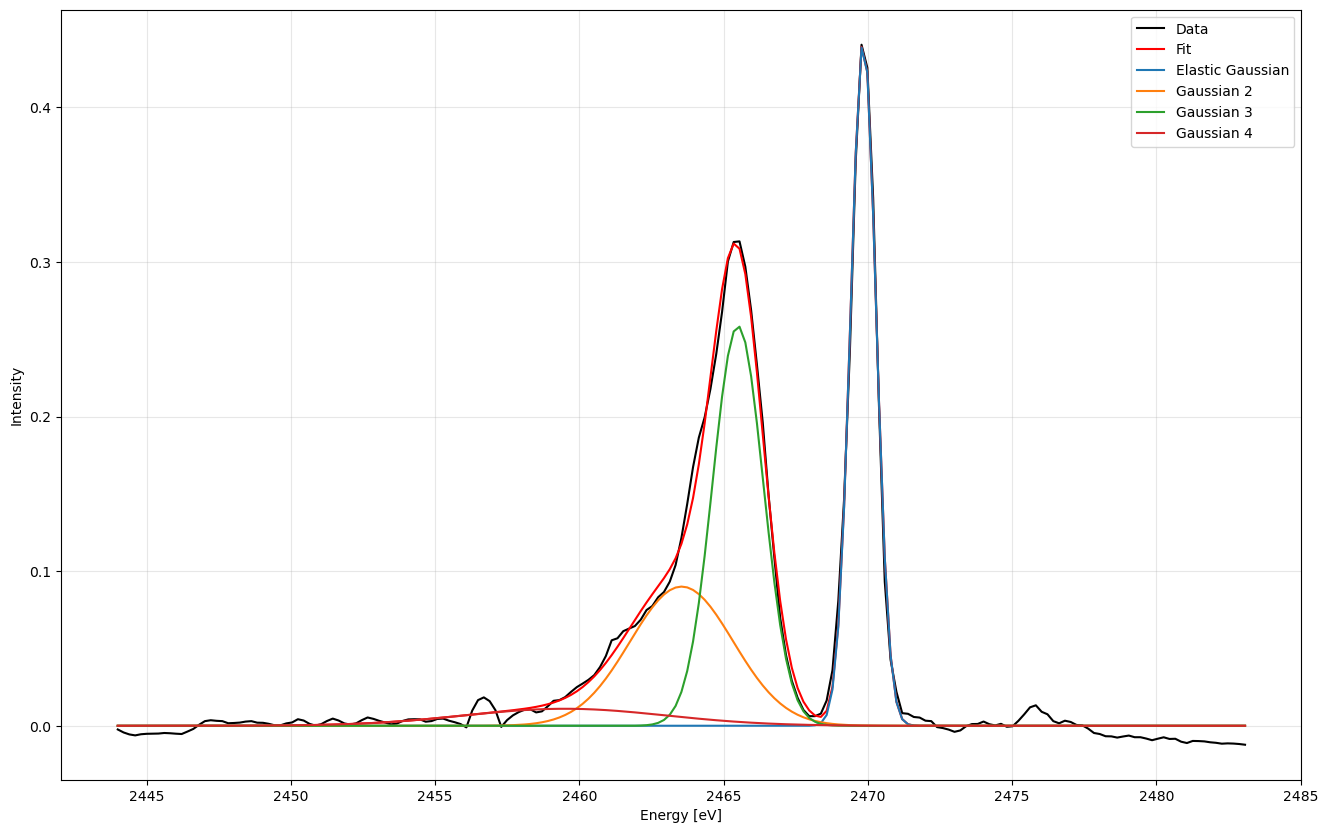

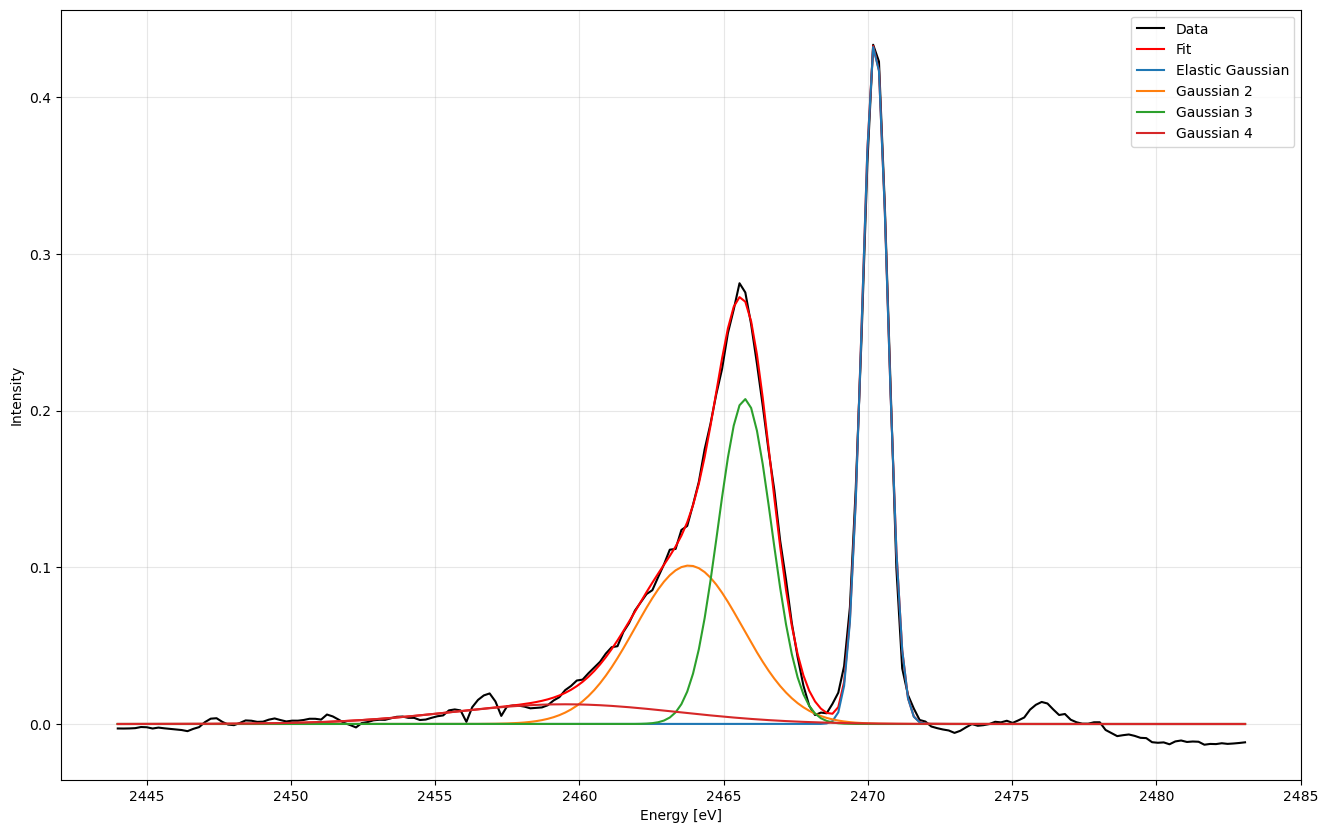

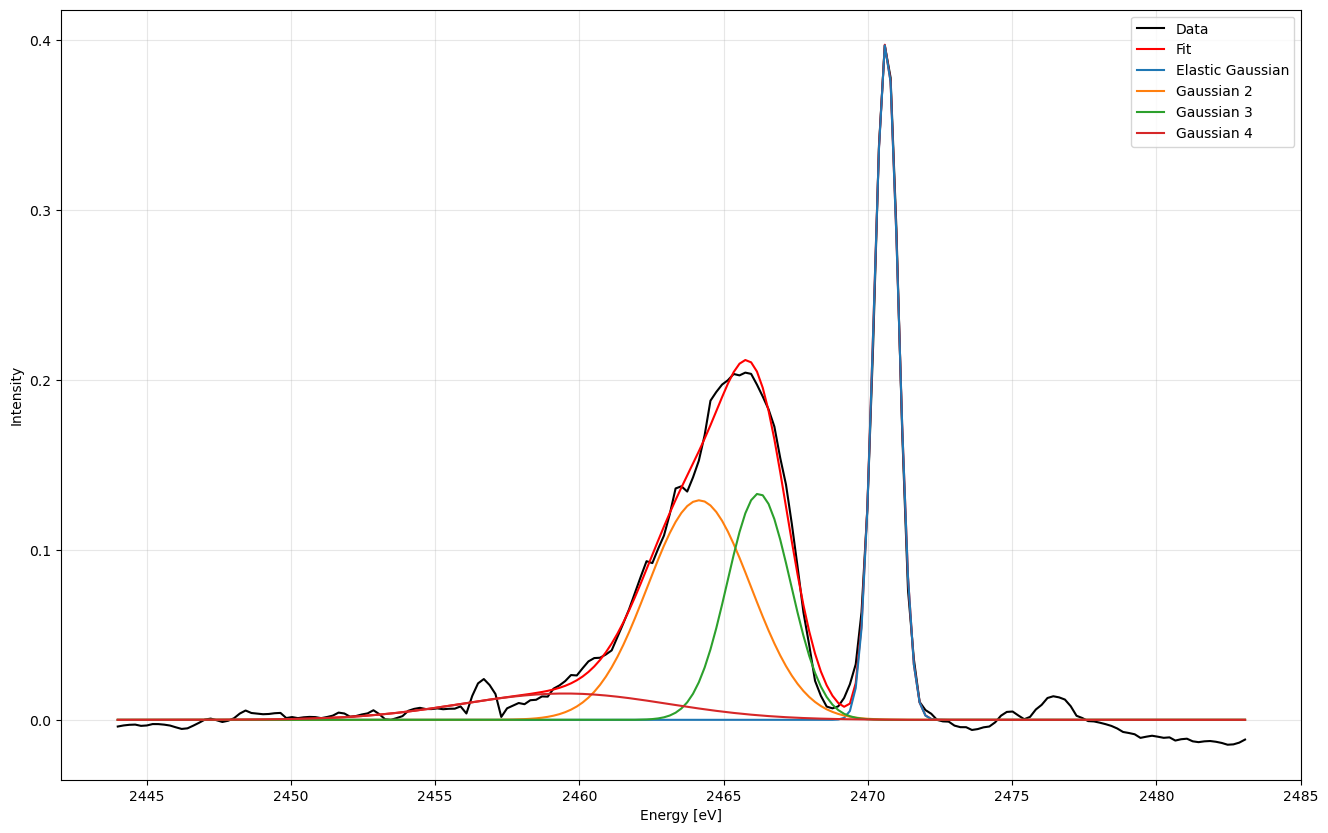

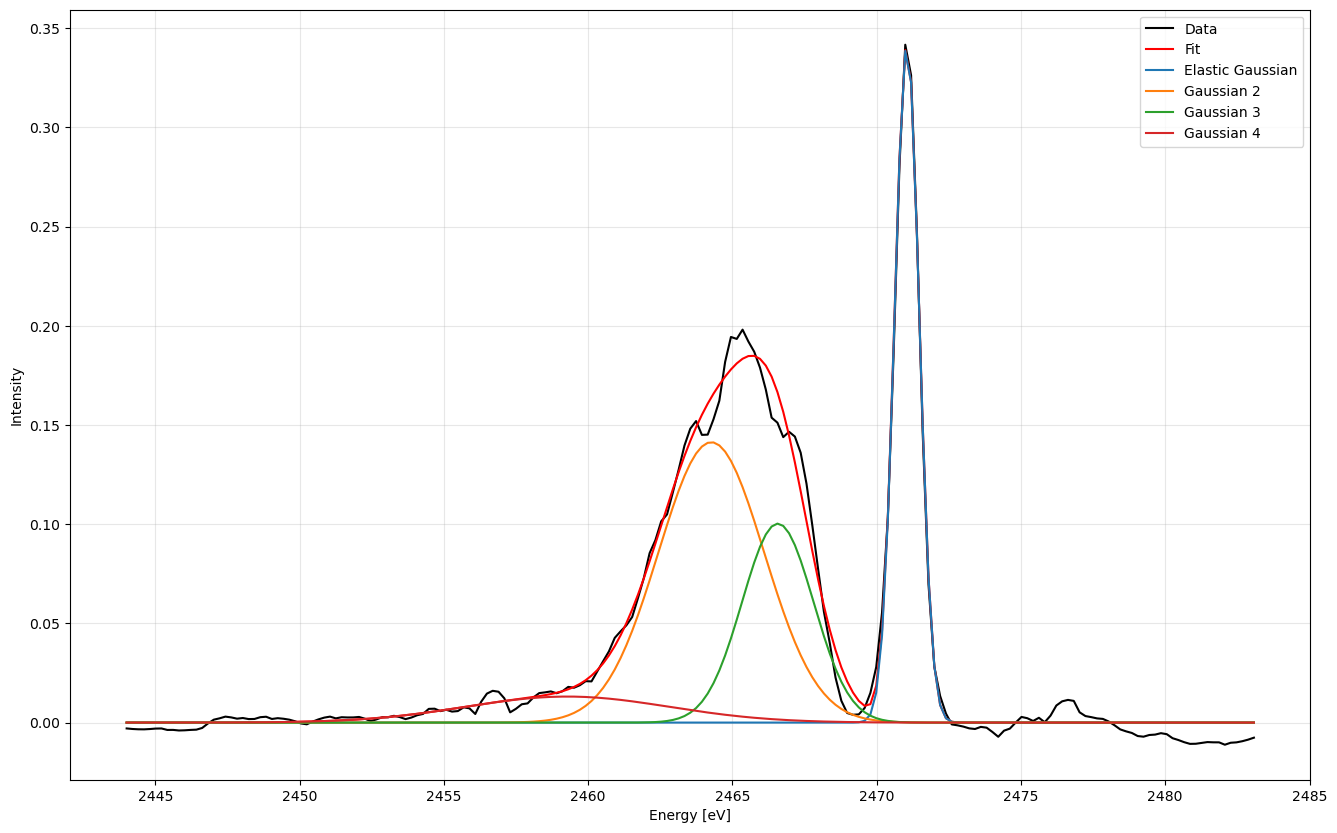

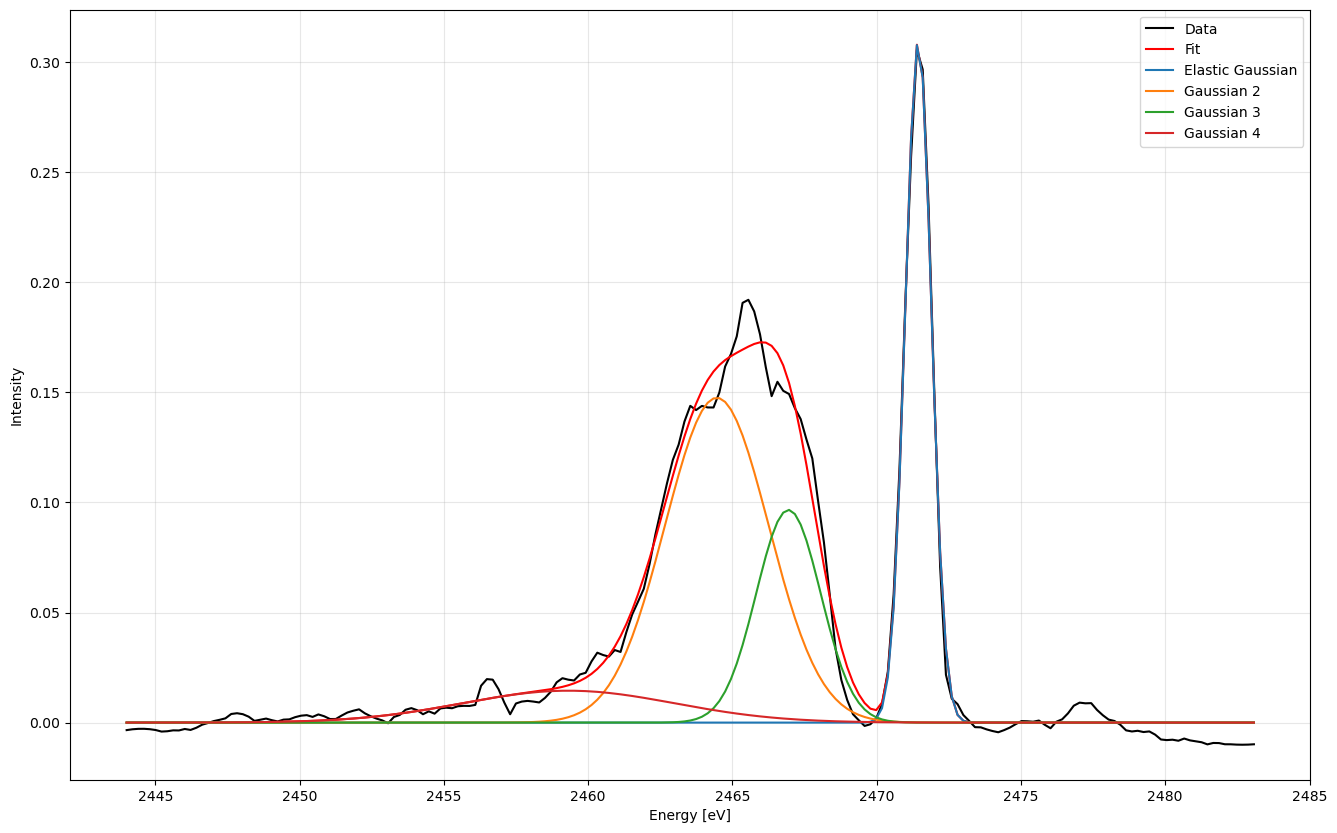

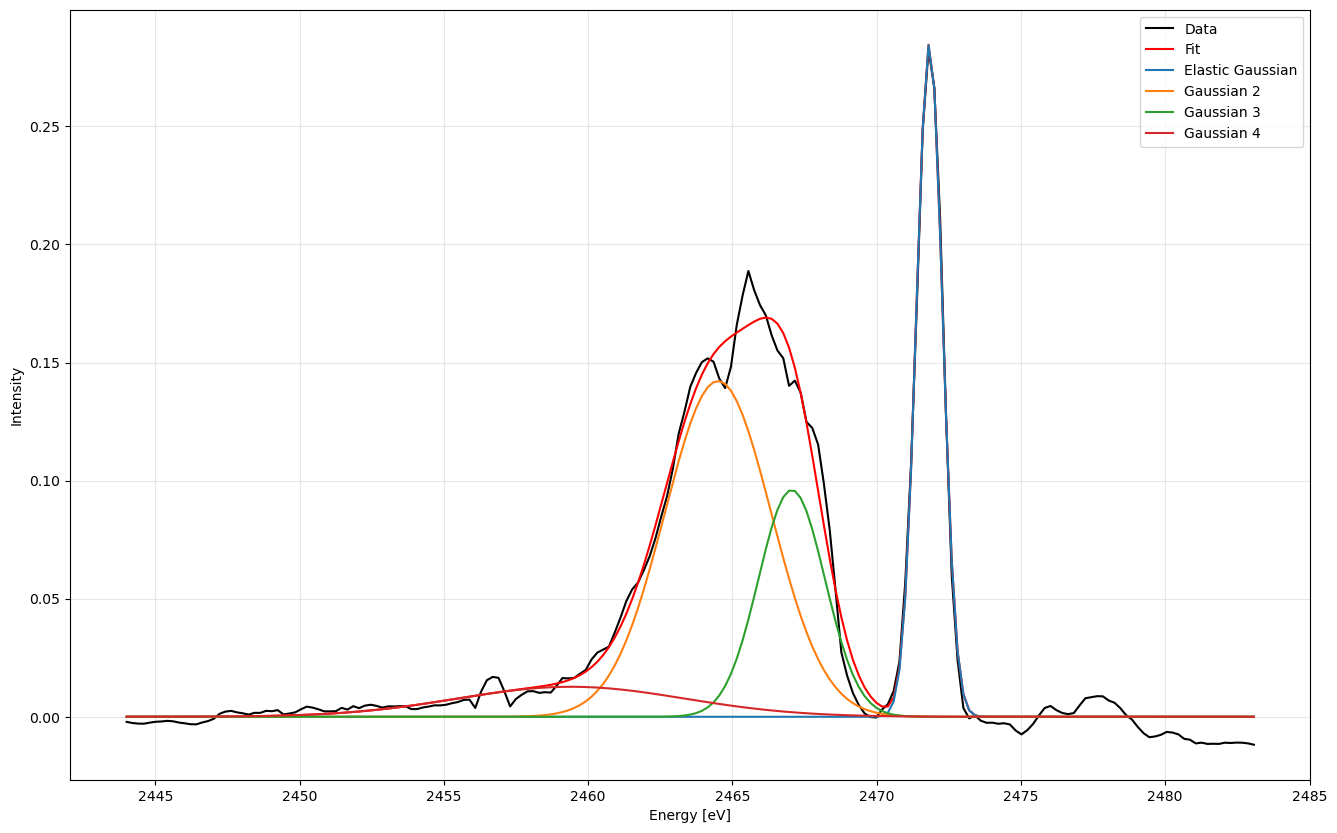

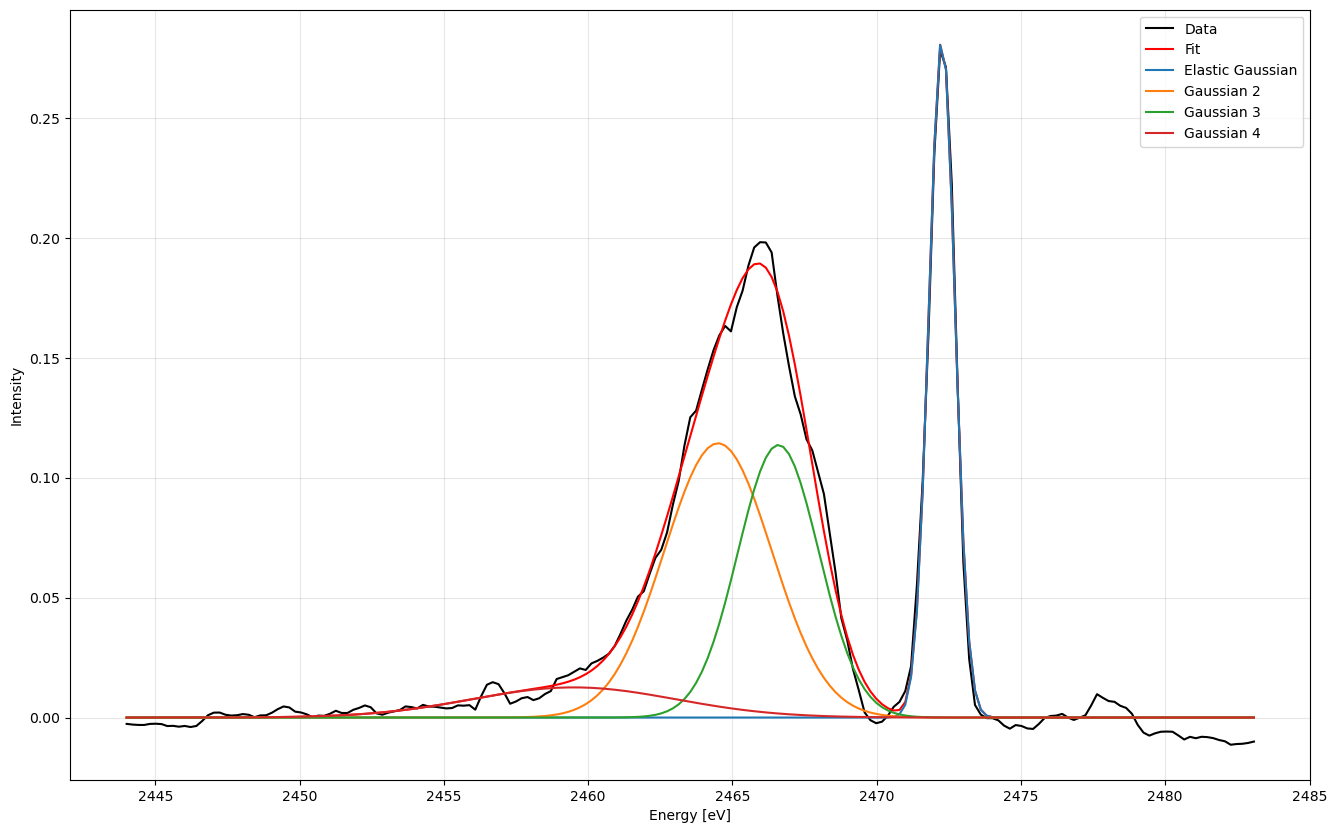

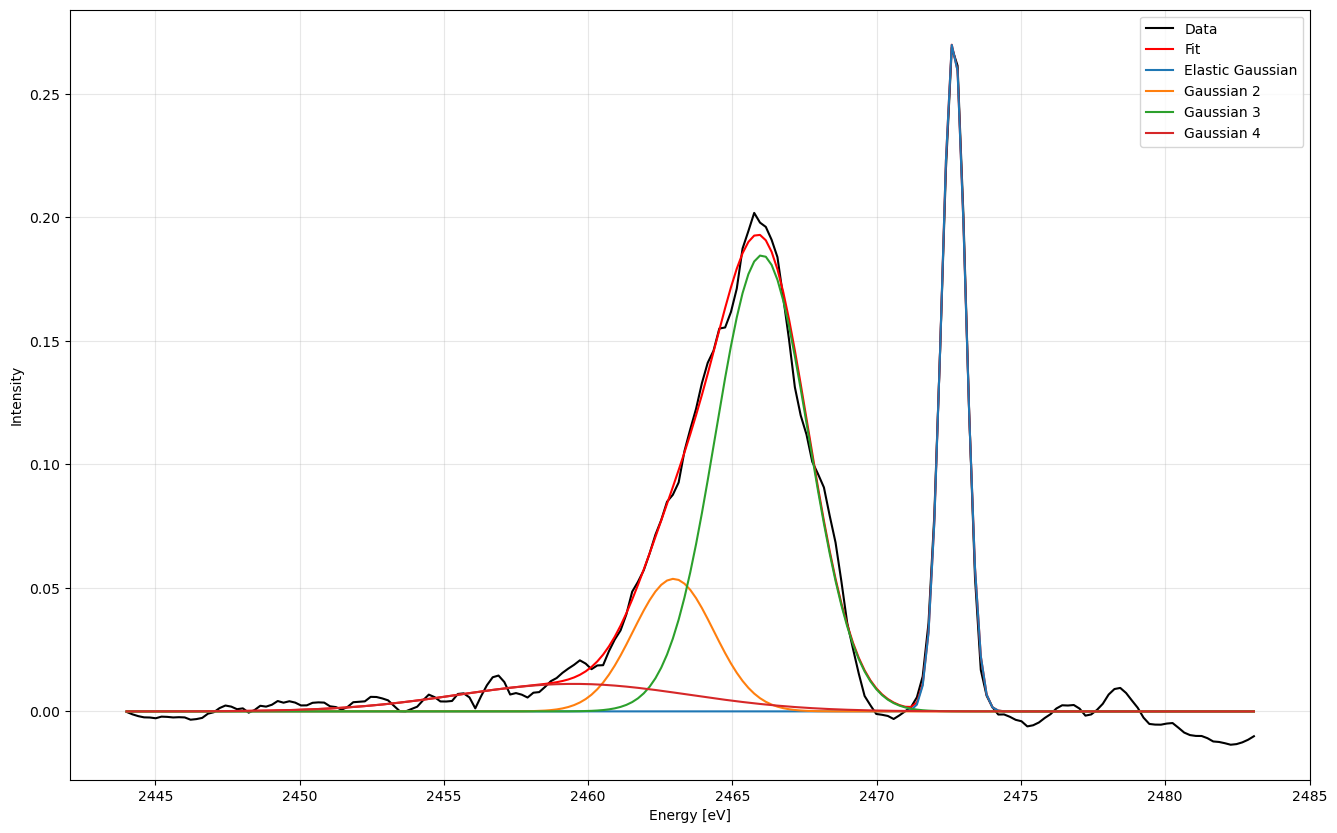

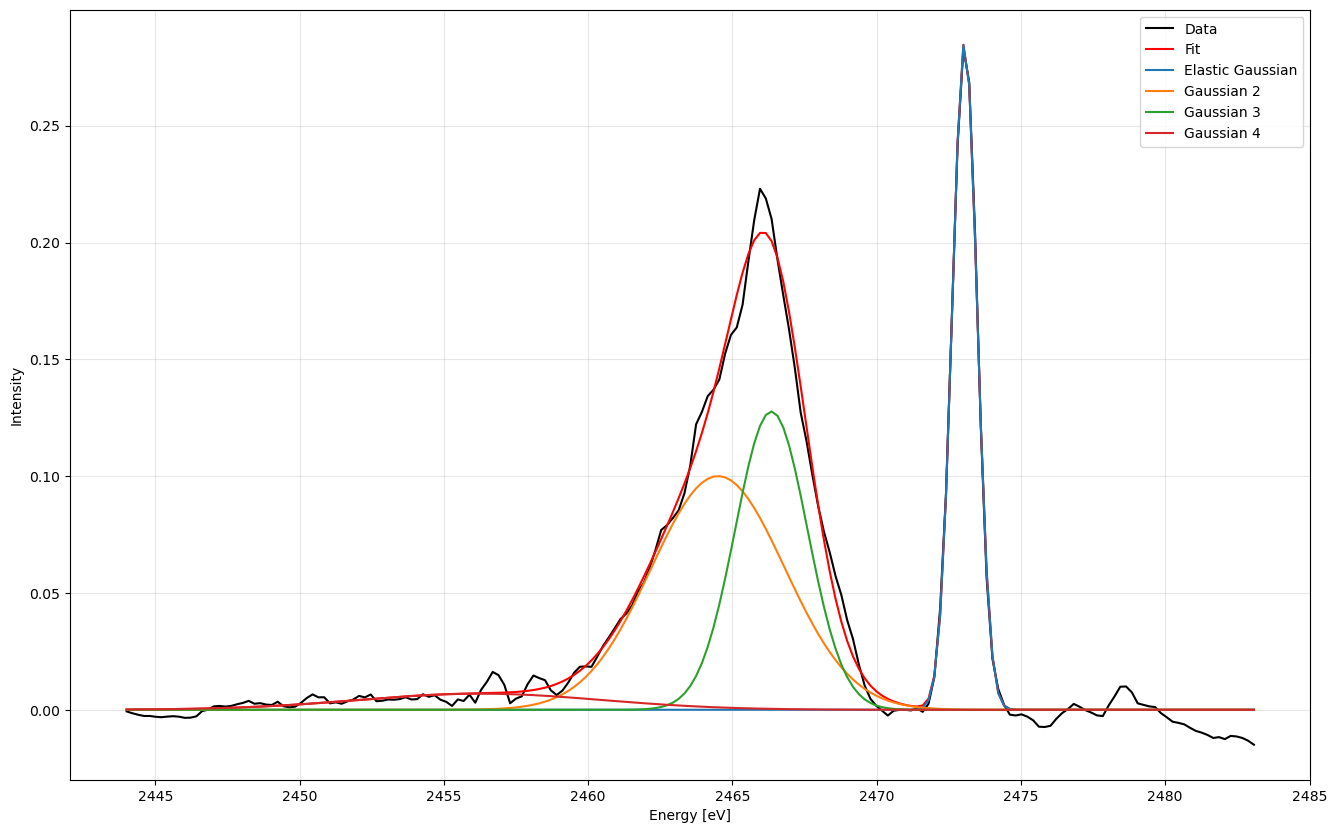

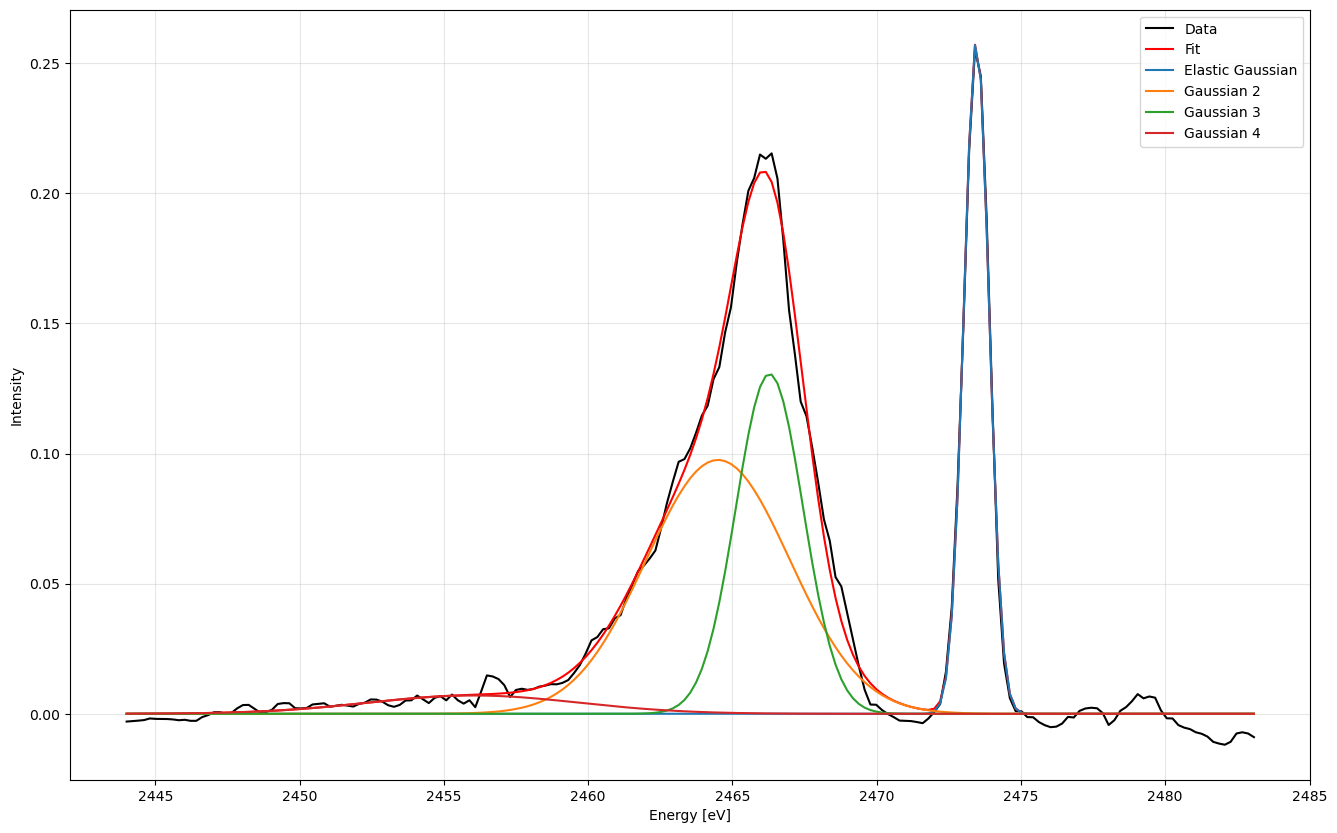

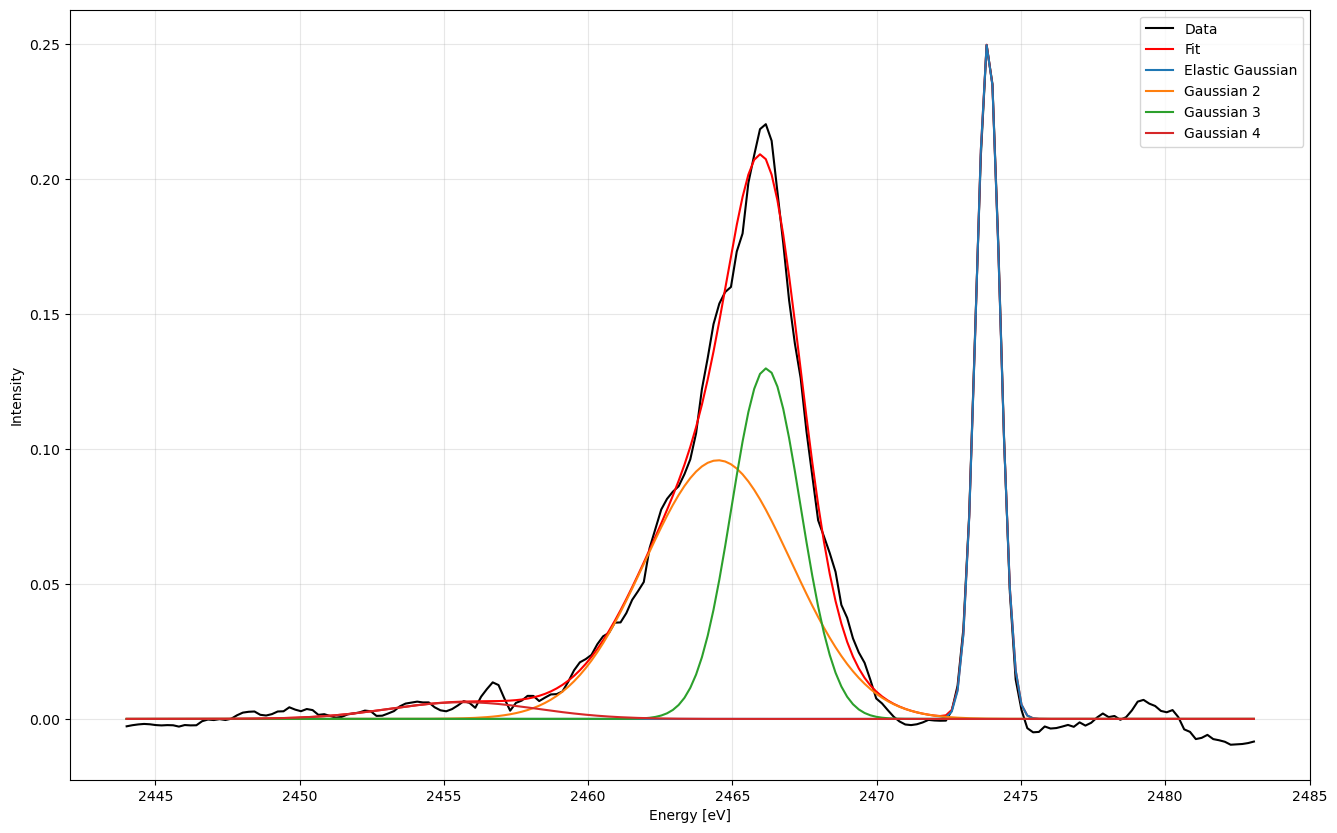

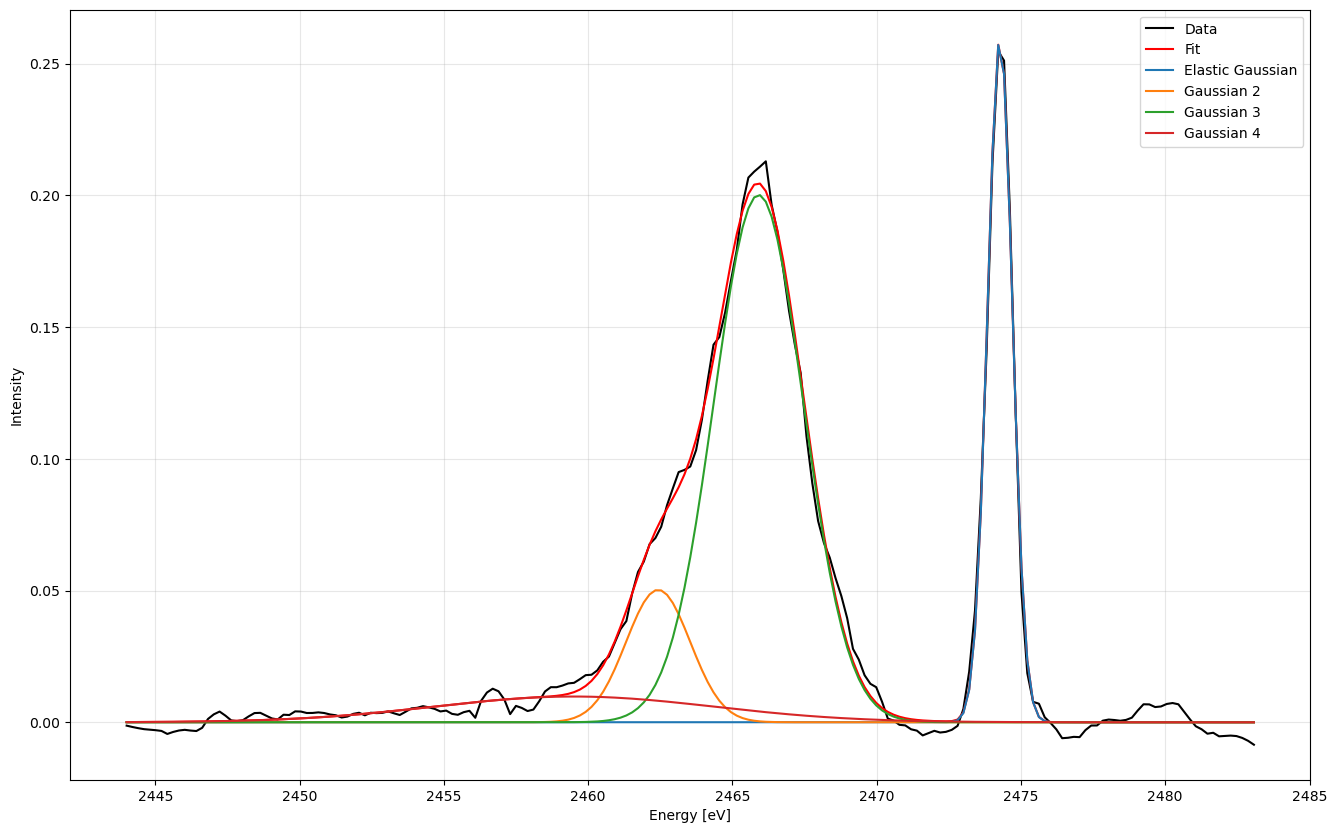

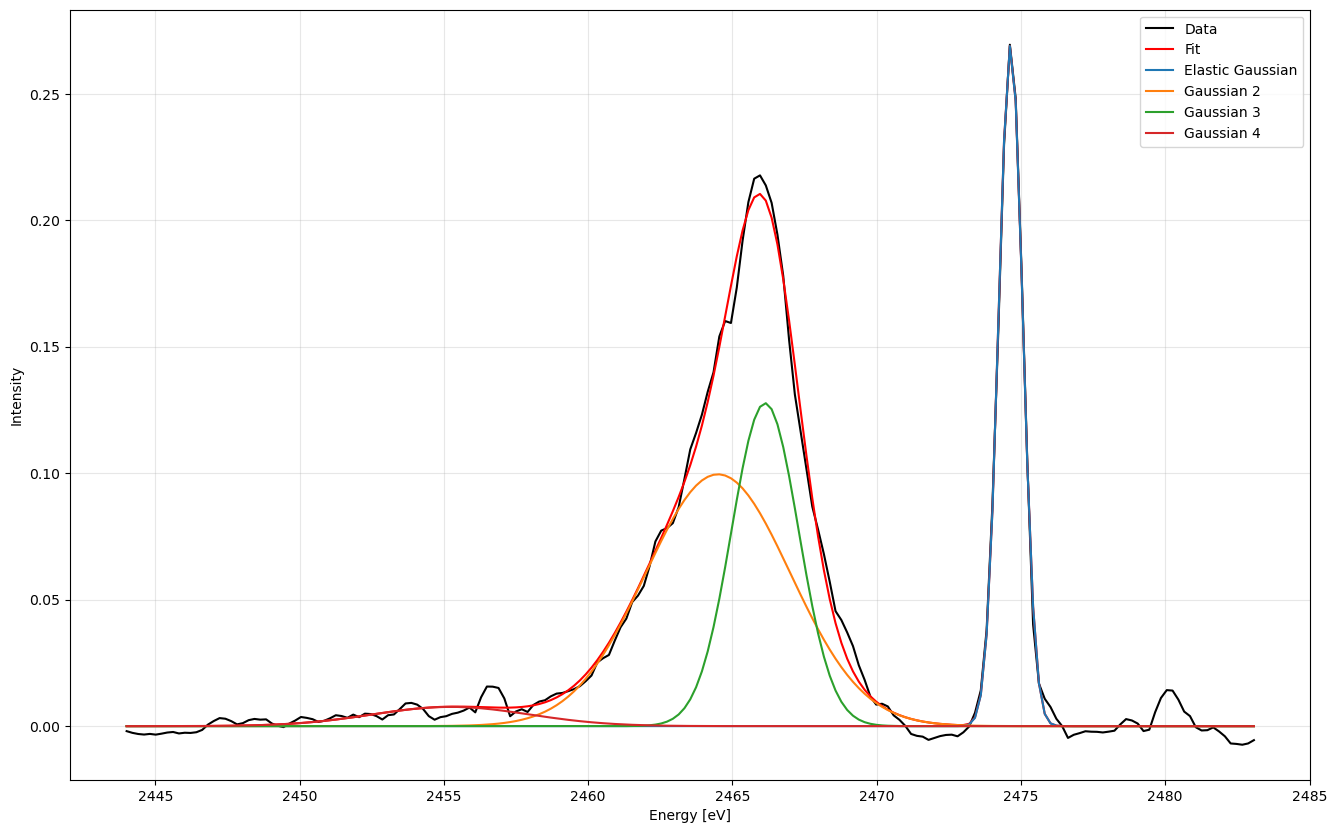

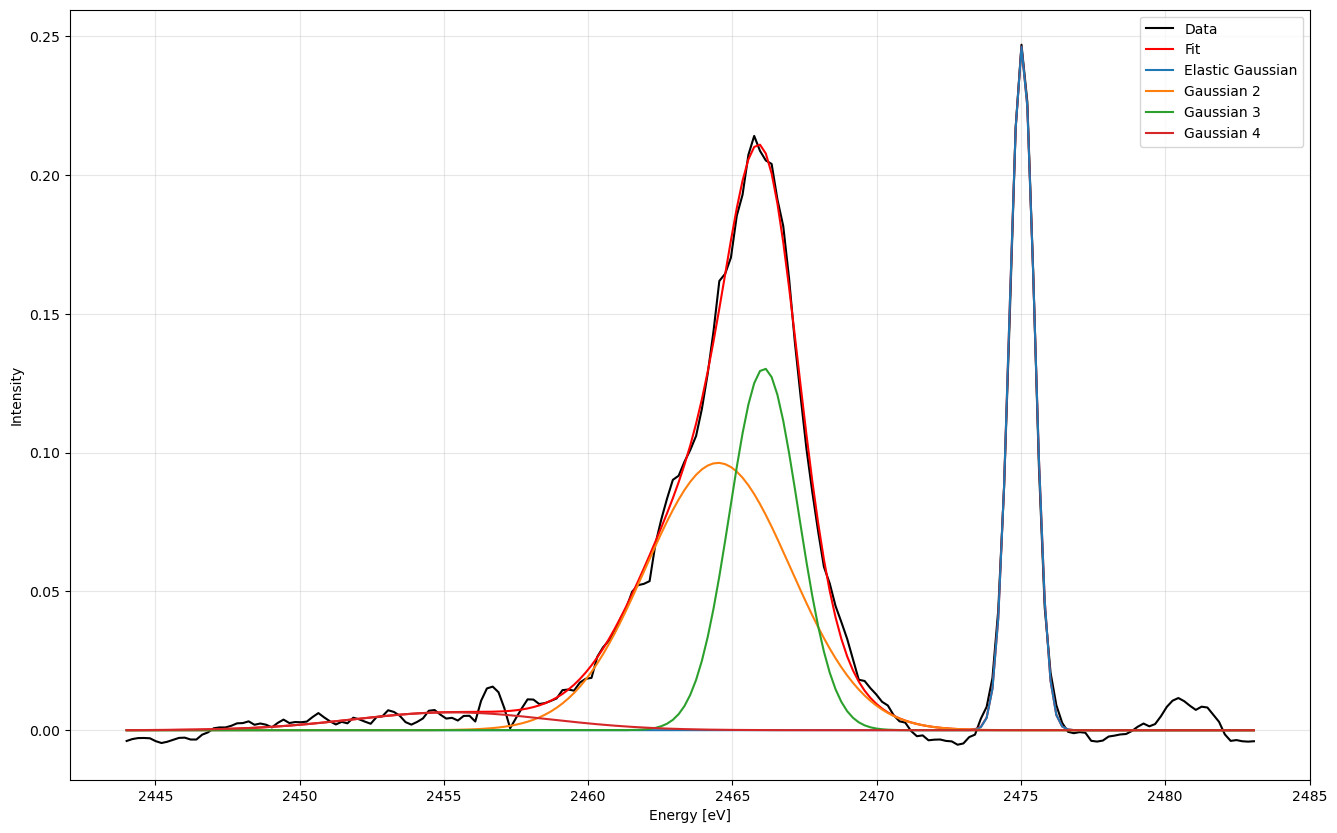

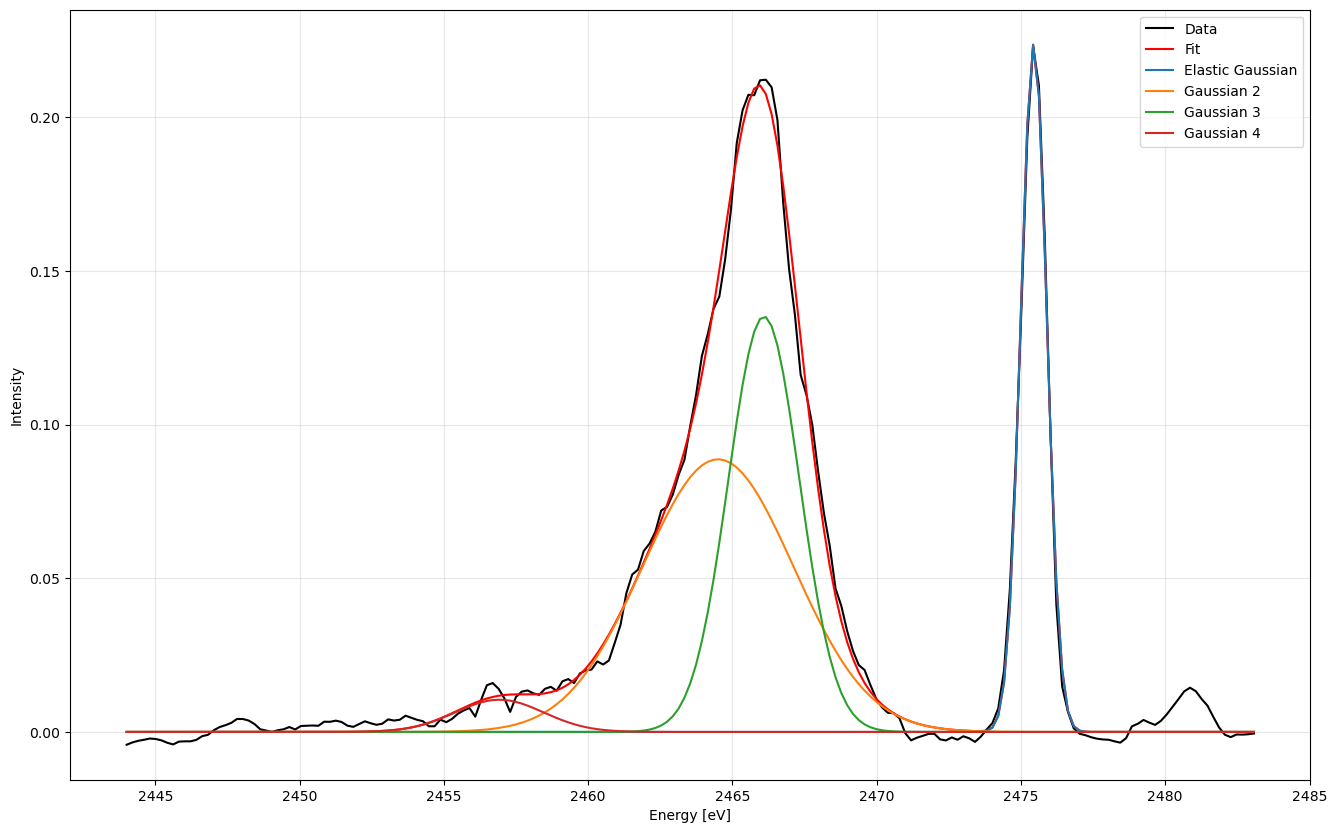

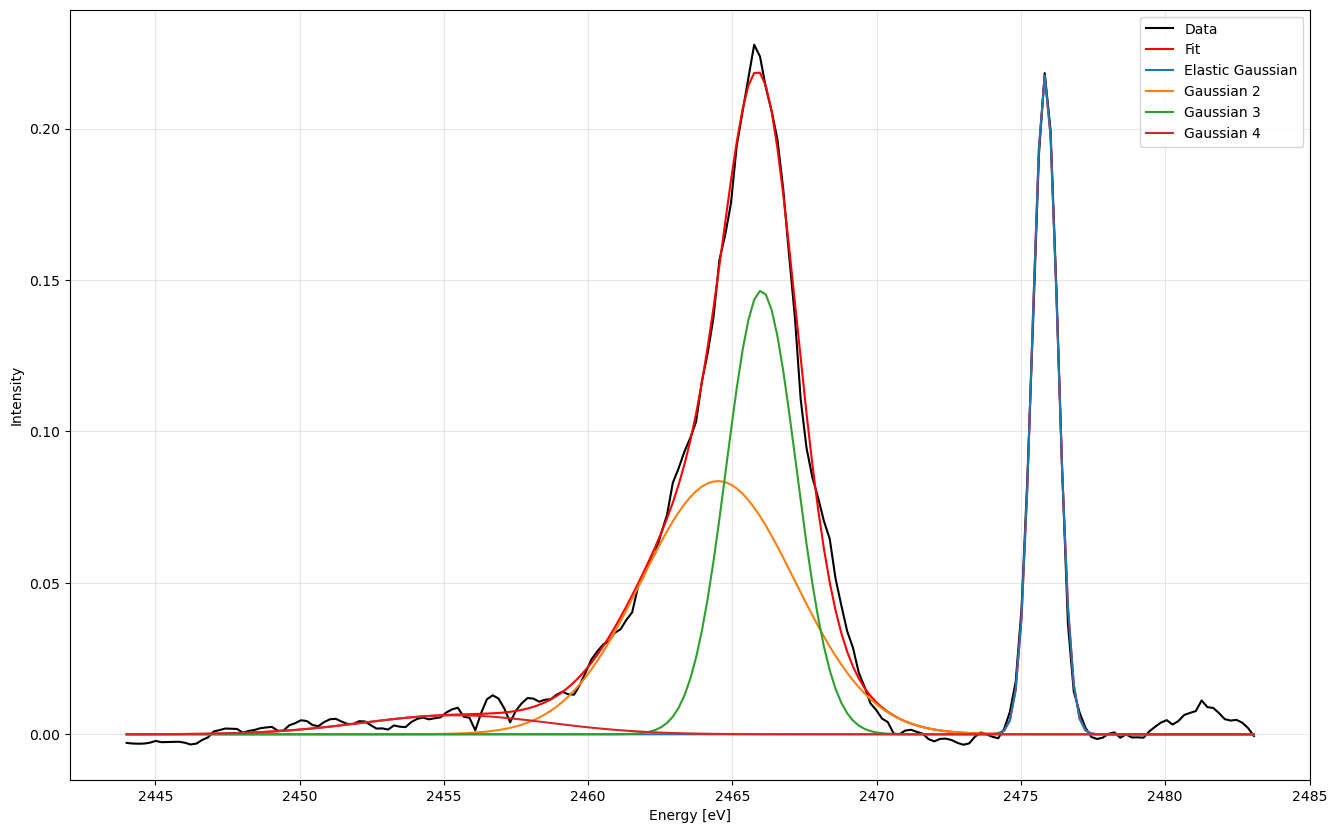

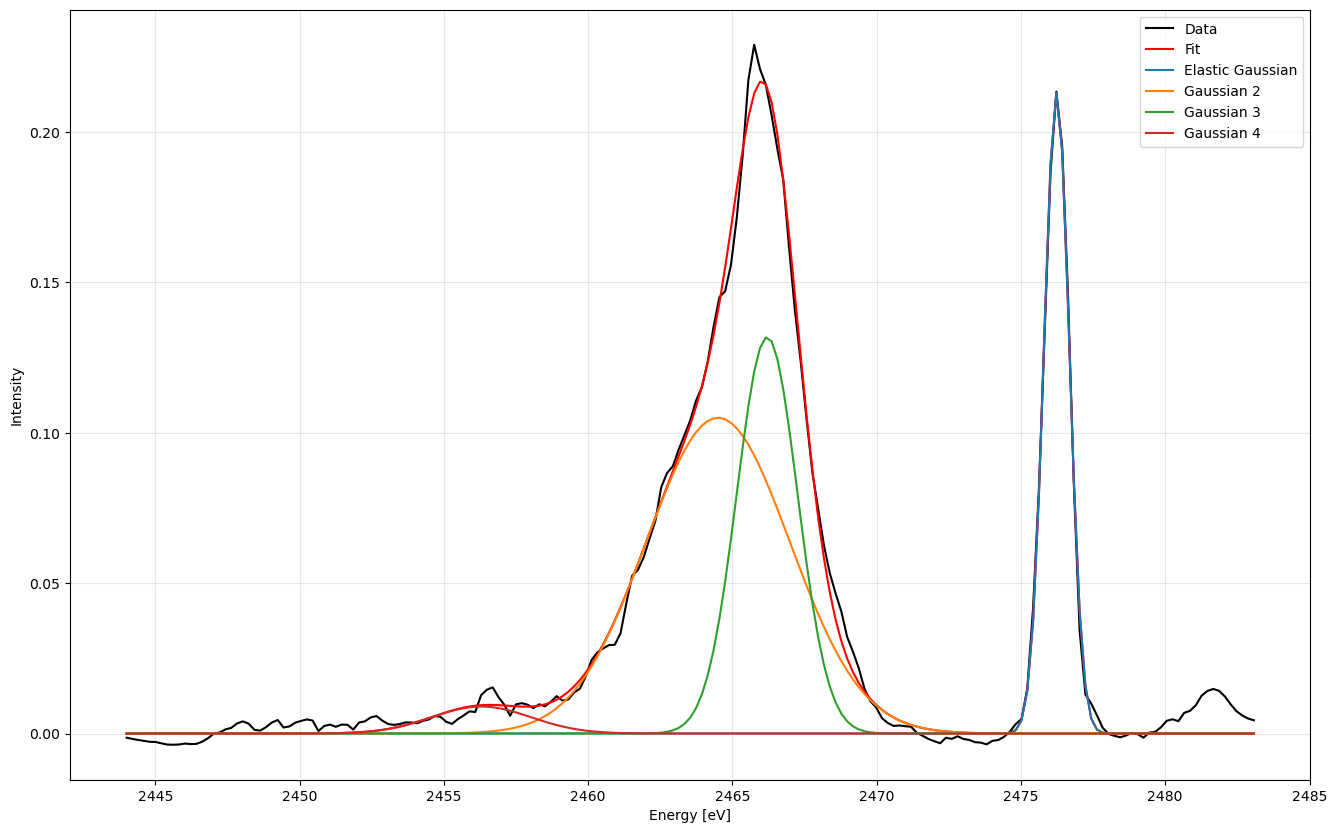

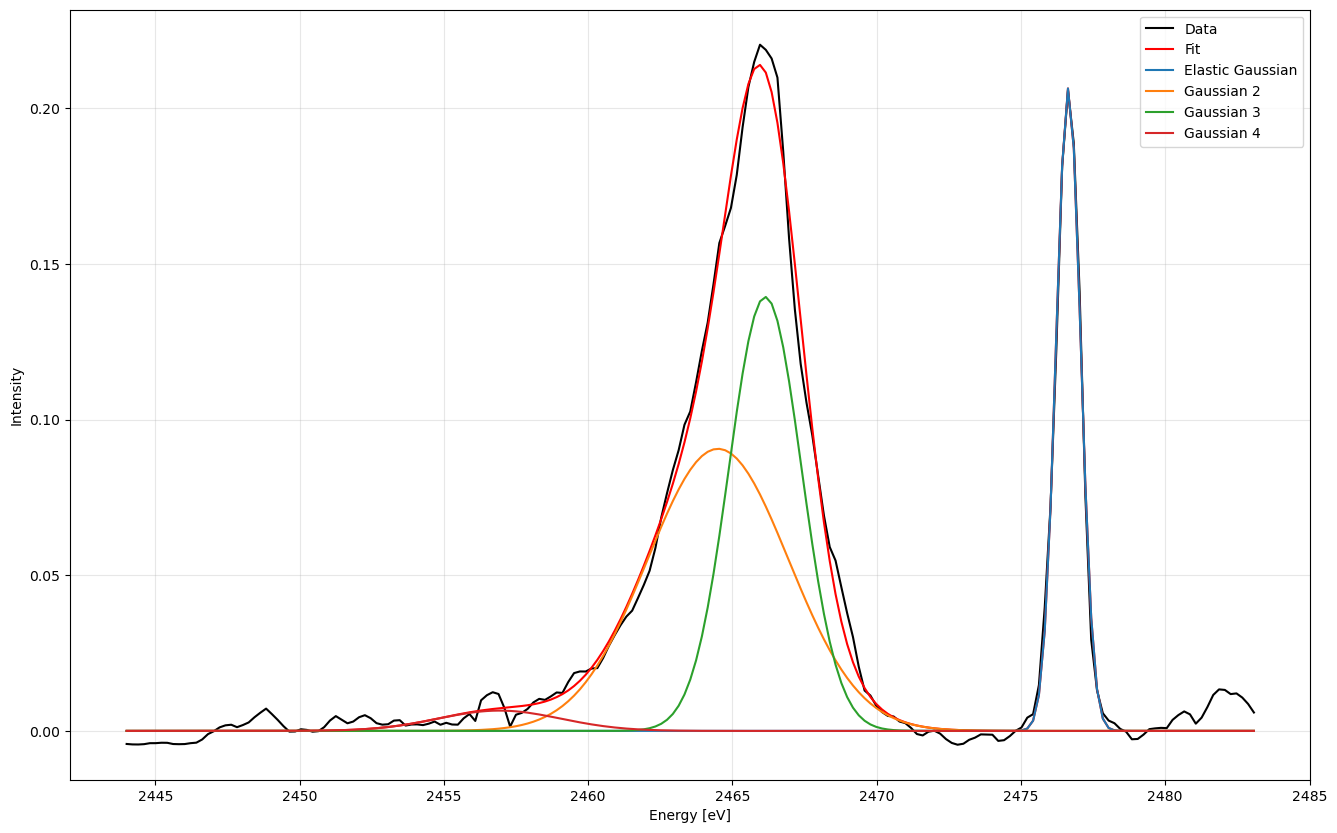

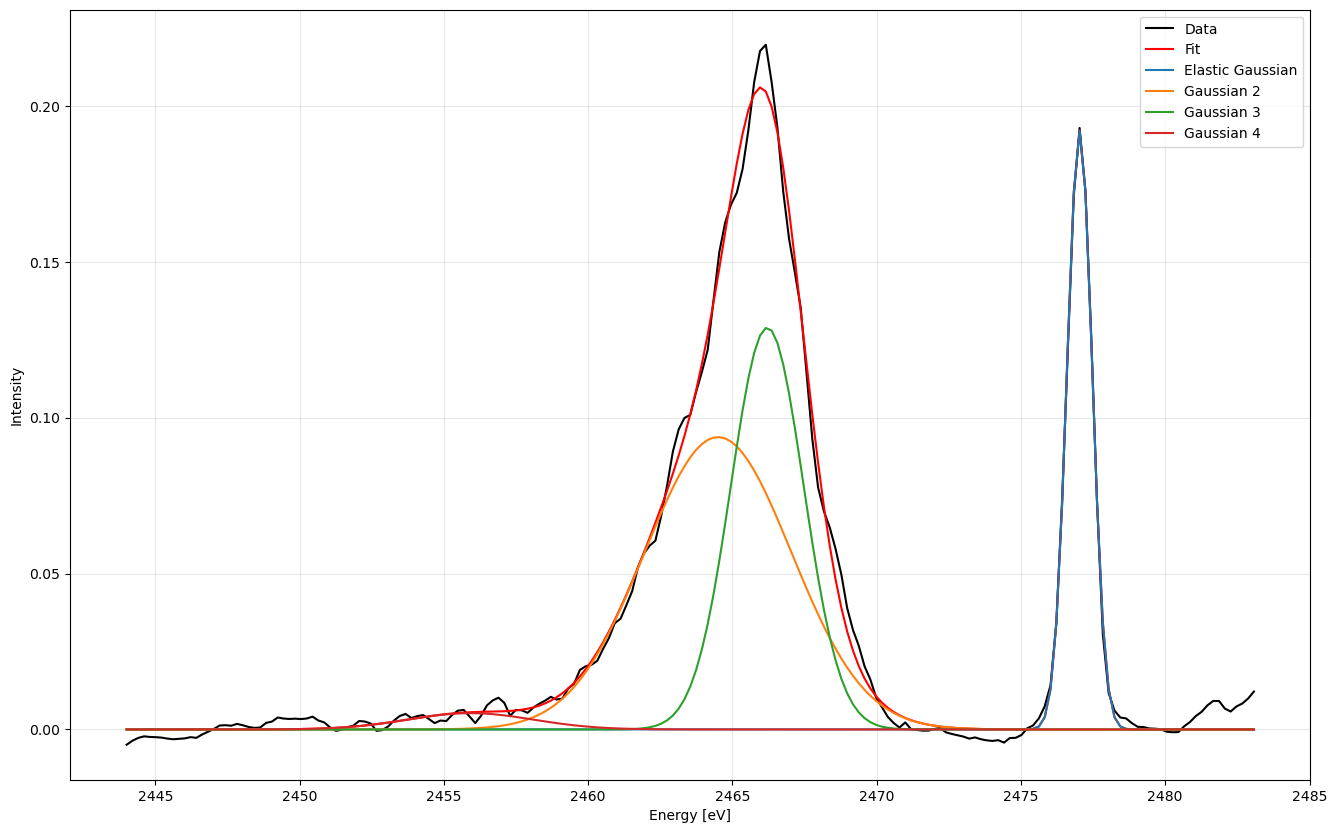

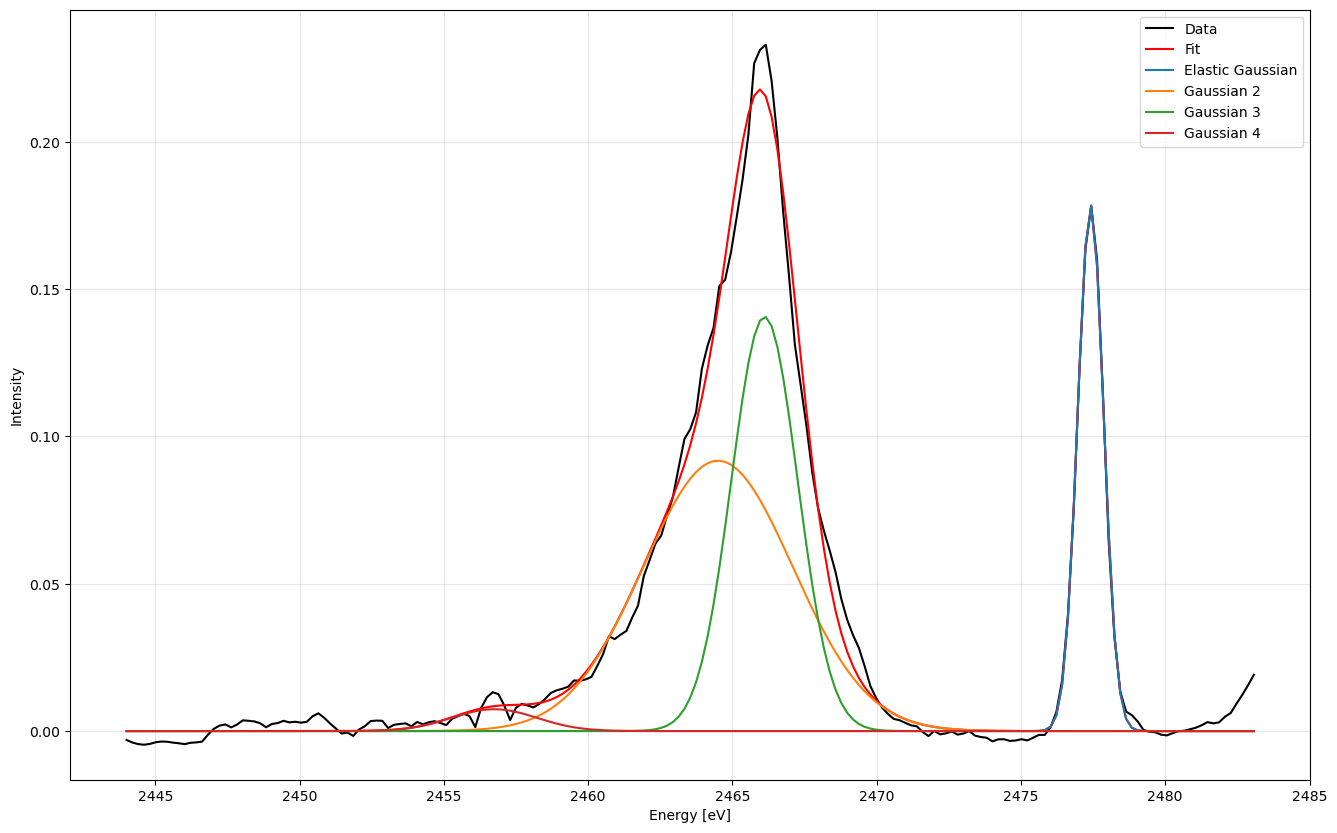

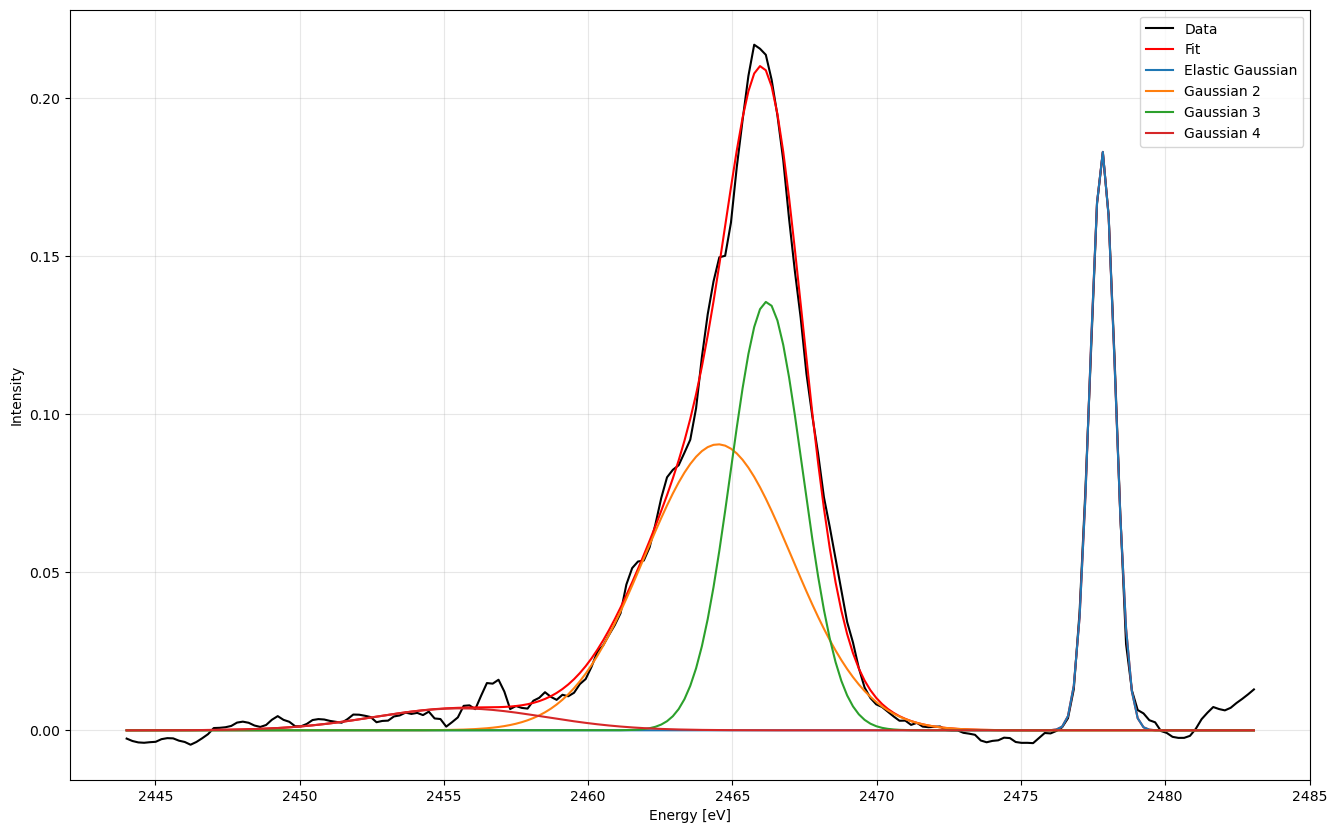

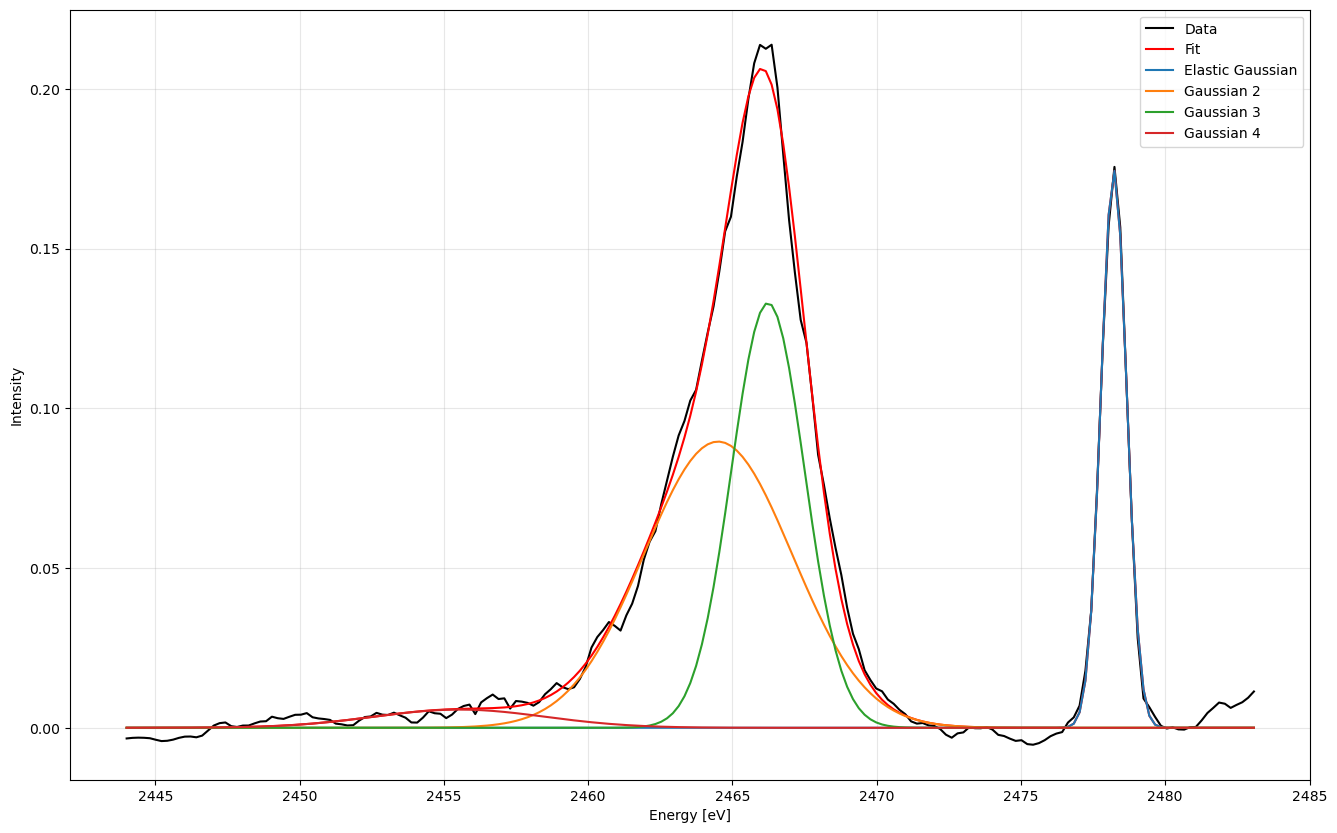

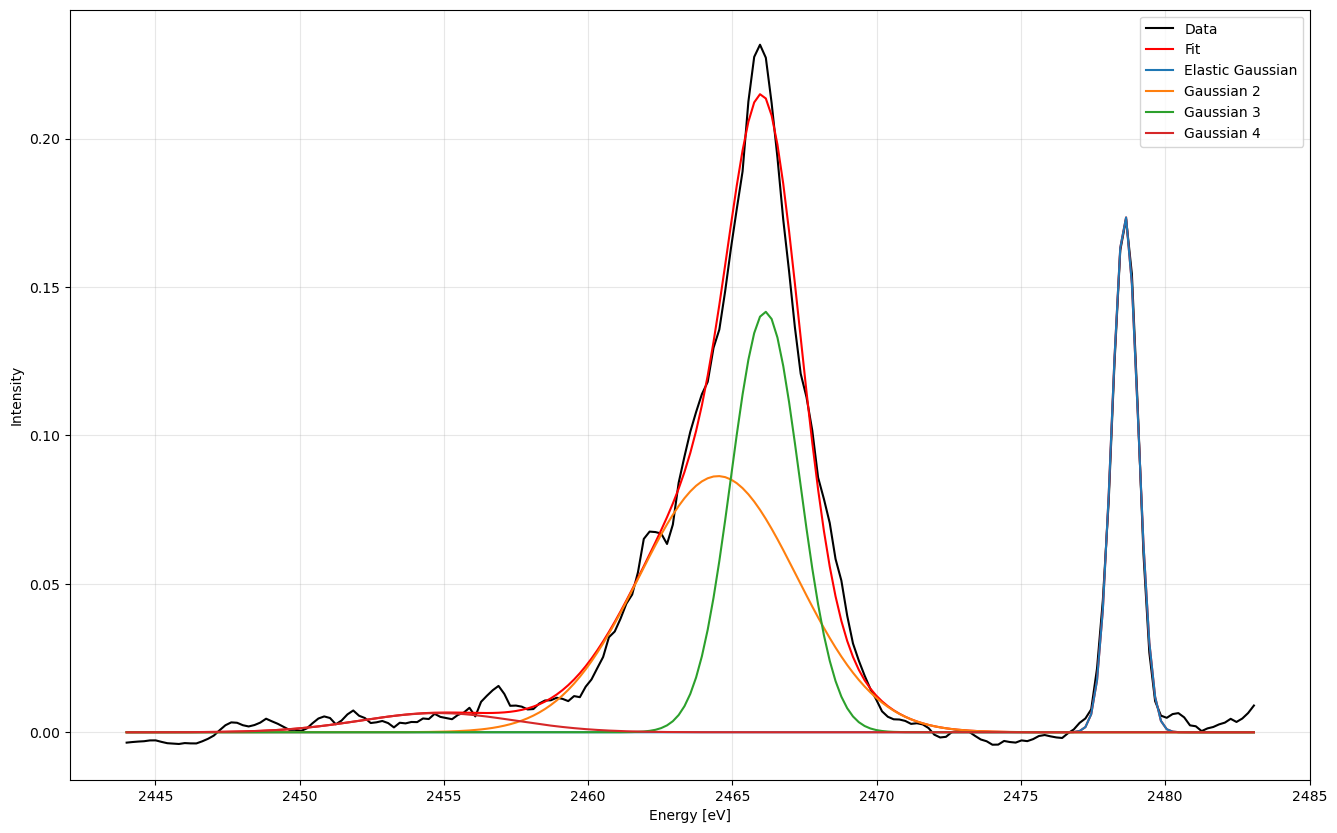

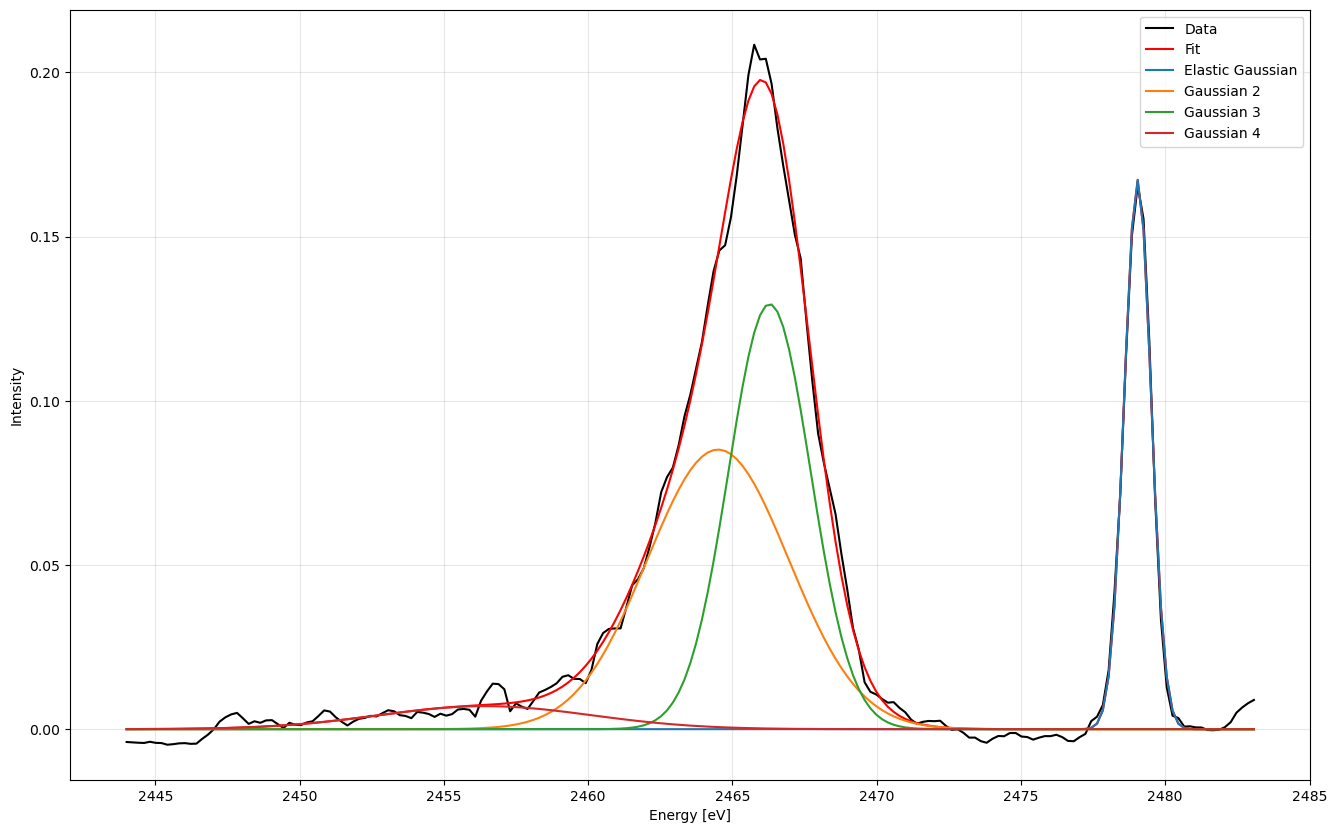

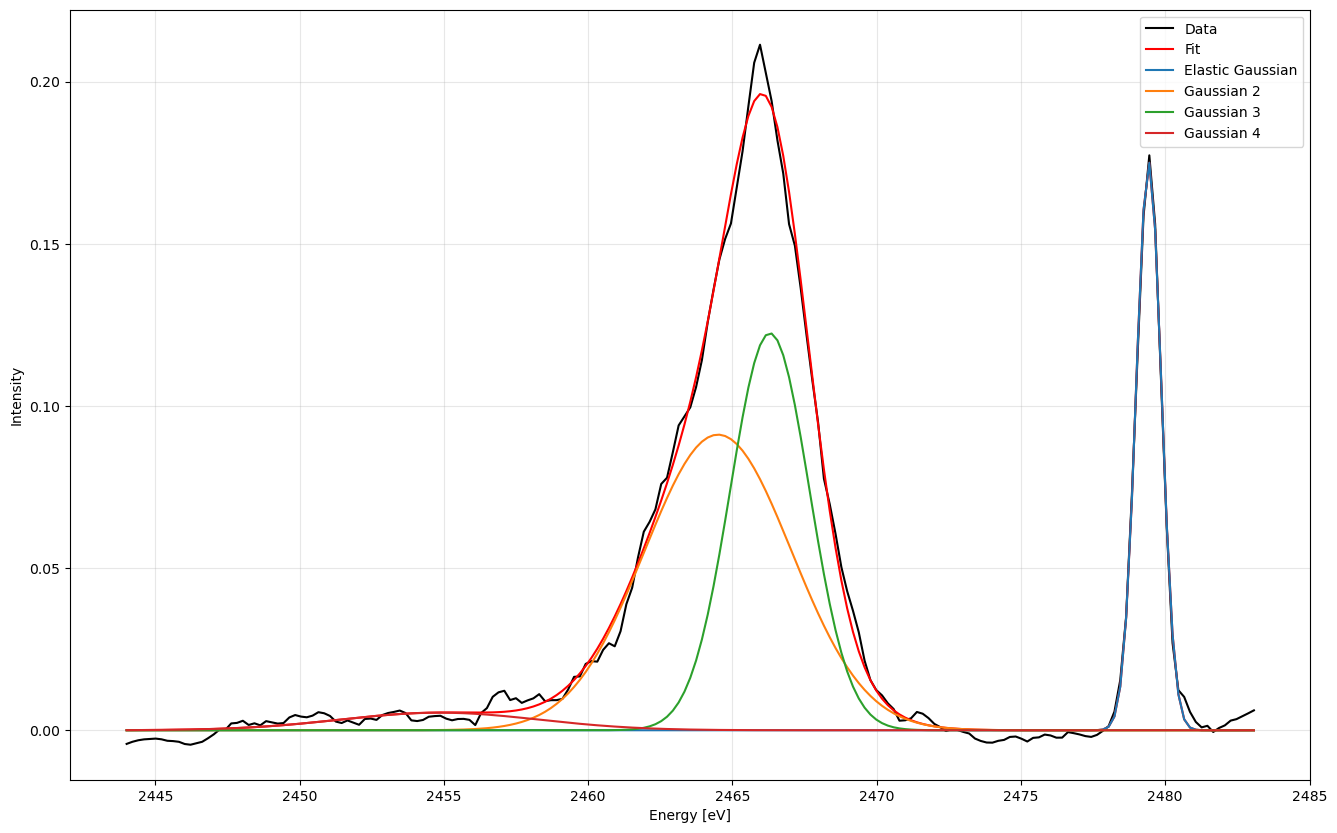

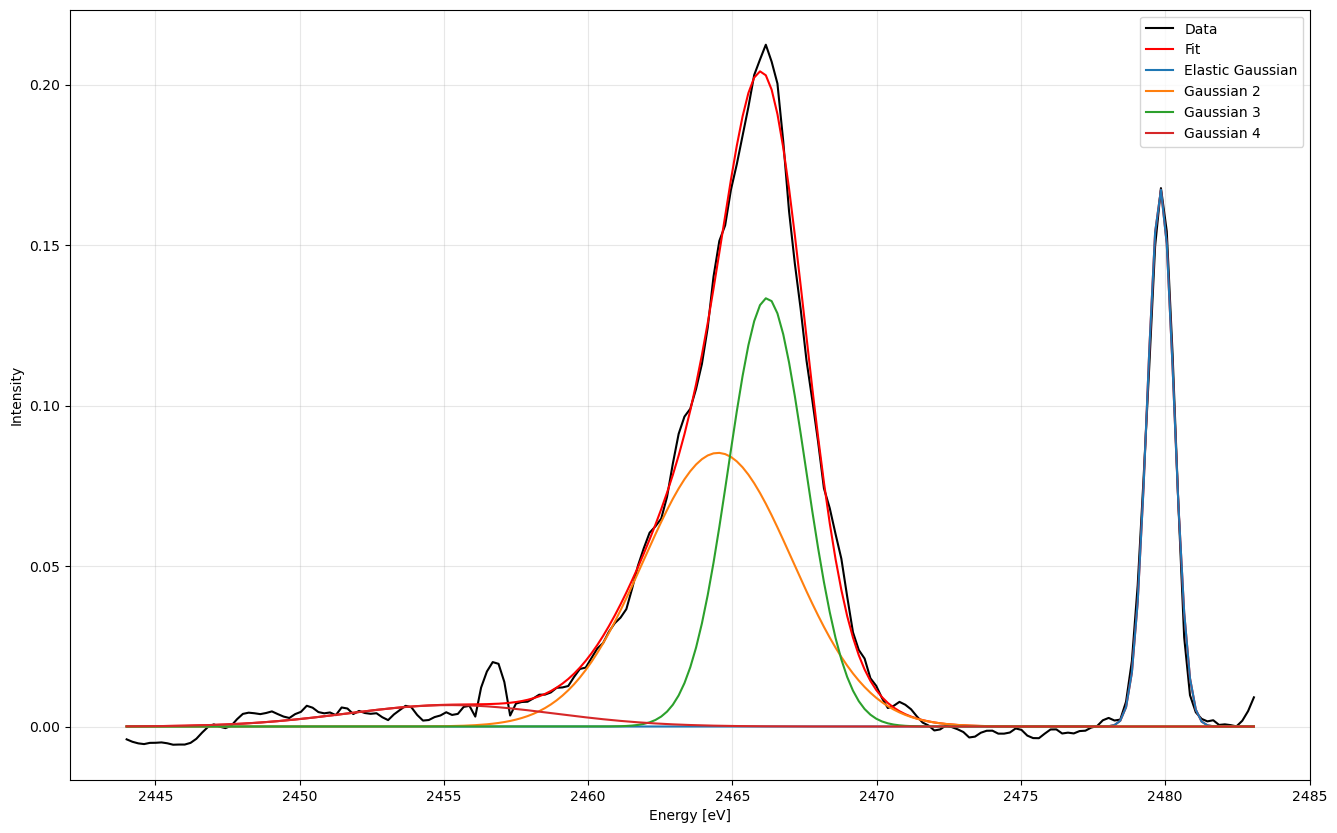

In [260]:
pristine = np.loadtxt('/home/ava/Documents/2025/GALAXIES25/Analysis/Soleil25_Ava/cache/Electrode_001/scan_0007/spectrum_ROI2_pilatus_xes.csv', skiprows = 1, delimiter = ',')

fig,axs = plt.subplots(1, 2, figsize=(16, 10))
i=2
limits = [2458,2467]
col_index=  np.arange(2468.0,2480.2,0.4)
while i < (len(pristine[0])):
    y =  pristine[:,i]
    x = pristine[:,0]
    x, y = smooth_data(x, y, window_length=7)
    x,y = remove_background(x, y, energy = col_index[i-1], plot = False)
    norm_lower_limit = limits[0]
    norm_upper_limit = limits[1]
    x, y = normalize_intensity(x, y, limits=(norm_lower_limit, col_index[i-1]-3))
    ax = axs[0]
    ax.plot(x,y+i*0.15, color = 'black')
    ax.text(2455,y[0]+i*0.155,f'{col_index[i-1]:.2f}',)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(2445,2485)
    ax.set_ylim(0.2,4.8)

    gauss_params, amp = fit_N_gaus(3, x,y, el_energy =col_index[i-1], plot=False)
    ax = axs[1]
    ax.scatter(col_index[i-1],gauss_params['g0_center'], color = 'tab:blue')
    ax.scatter(col_index[i-1],gauss_params['g1_center'], color = 'tab:orange')
    ax.scatter(col_index[i-1],gauss_params['g2_center'], color = 'tab:green')
    ax.scatter(col_index[i-1],gauss_params['g3_center'], color = 'tab:red')
    #ax.set_ylim(2450,2480)
    i=i+1

In [101]:

np.arange(2468.4,2471.7,0.4)

array([2468.4, 2468.8, 2469.2, 2469.6, 2470. , 2470.4, 2470.8, 2471.2,
       2471.6])

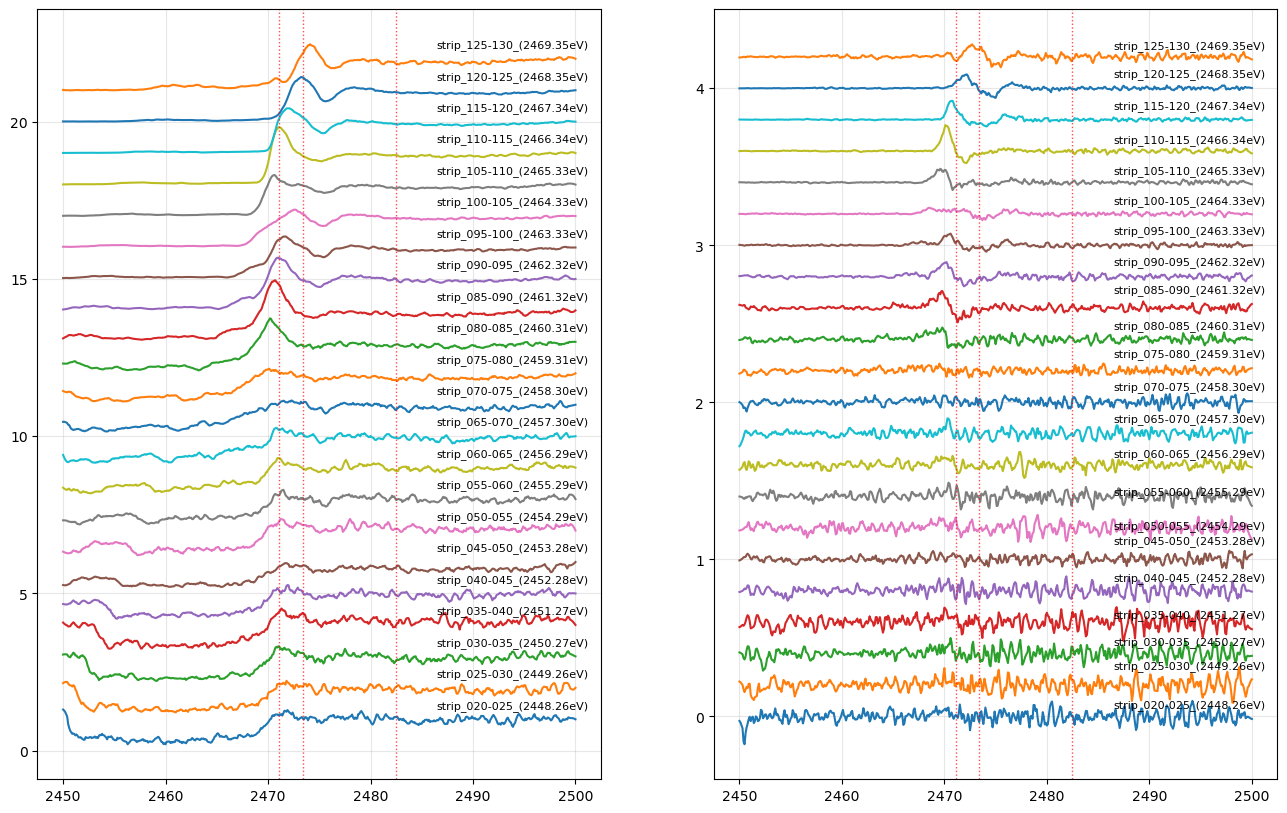

In [261]:
#veertical strips

data = np.loadtxt('/home/ava/Documents/2025/GALAXIES25/Analysis/Soleil25_Ava/cache/Electrode_001/scan_0007/spectrum_ROI2_pilatus_xas_strips_clean_w5px_step5_sum_half10px_drop15px.csv', skiprows = 1, delimiter = ',')

csv_path = '/home/ava/Documents/2025/GALAXIES25/Analysis/Soleil25_Ava/cache/Electrode_001/scan_0007/spectrum_ROI2_pilatus_xas_strips_clean_w5px_step5_sum_half10px_drop15px.csv'

import pandas as pd
df = pd.read_csv(csv_path)

fig, axs = plt.subplots(1, 2, figsize=(16, 10))
x = df.iloc[:, 0].to_numpy()

start_col = 5
end_col = df.shape[1] - 10

for col in range(start_col, end_col):
    label = df.columns[col]
    y = df.iloc[:, col].to_numpy()
    x_s, y_s = smooth_data(x, y, window_length=10)
    y_n = y_s / y_s[-1]
    o0 = 1 * (col - start_col)
    o1 = 0.2 * (col - start_col)

    axs[0].plot(x_s, y_n + o0)
    axs[1].plot(x_s, np.gradient(y_n) + o1)

    axs[0].annotate(label, (x_s[-1], y_n[-1] + o0),
                    xytext=(-100,10), textcoords='offset points', va='center', fontsize=8, clip_on=False)
    axs[1].annotate(label, (x_s[-1], np.gradient(y_n)[-1] + o1),
                    xytext=(-100,10), textcoords='offset points', va='center', fontsize=8, clip_on=False)

battery_lines = [2471.1, 2473.4,2482.5]
for line in battery_lines:
    axs[0].axvline(line, color='red', ls=':', alpha = 0.7, linewidth = 1)
    axs[1].axvline(line, color='red', ls=':', alpha = 0.7, linewidth = 1)

axs[0].grid(True, alpha=0.3)
axs[1].grid(True, alpha=0.3)
